In [1]:
from sklearn.preprocessing import PowerTransformer, RobustScaler, StandardScaler
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
from sklearn import pipeline
from rdkit import Chem
import pandas as pd
import numpy as np
import sklearn
import scipy

In [9]:
from itertools import product


folds = np.arange(25)
sizes = [0.1, 0.25, 0.5, 0.75, 1]

list(product(folds, sizes))

[(np.int64(0), 0.1),
 (np.int64(0), 0.25),
 (np.int64(0), 0.5),
 (np.int64(0), 0.75),
 (np.int64(0), 1),
 (np.int64(1), 0.1),
 (np.int64(1), 0.25),
 (np.int64(1), 0.5),
 (np.int64(1), 0.75),
 (np.int64(1), 1),
 (np.int64(2), 0.1),
 (np.int64(2), 0.25),
 (np.int64(2), 0.5),
 (np.int64(2), 0.75),
 (np.int64(2), 1),
 (np.int64(3), 0.1),
 (np.int64(3), 0.25),
 (np.int64(3), 0.5),
 (np.int64(3), 0.75),
 (np.int64(3), 1),
 (np.int64(4), 0.1),
 (np.int64(4), 0.25),
 (np.int64(4), 0.5),
 (np.int64(4), 0.75),
 (np.int64(4), 1),
 (np.int64(5), 0.1),
 (np.int64(5), 0.25),
 (np.int64(5), 0.5),
 (np.int64(5), 0.75),
 (np.int64(5), 1),
 (np.int64(6), 0.1),
 (np.int64(6), 0.25),
 (np.int64(6), 0.5),
 (np.int64(6), 0.75),
 (np.int64(6), 1),
 (np.int64(7), 0.1),
 (np.int64(7), 0.25),
 (np.int64(7), 0.5),
 (np.int64(7), 0.75),
 (np.int64(7), 1),
 (np.int64(8), 0.1),
 (np.int64(8), 0.25),
 (np.int64(8), 0.5),
 (np.int64(8), 0.75),
 (np.int64(8), 1),
 (np.int64(9), 0.1),
 (np.int64(9), 0.25),
 (np.int64(9

In [65]:
def make_pipeline(model):
    return pipeline.Pipeline([
        ("transform", PowerTransformer(method='yeo-johnson', standardize=False)),
        ("scale", RobustScaler()),
        ("predict", model)
    ])

In [66]:
pl = make_pipeline(sklearn.linear_model.LinearRegression())

In [67]:
rng = np.random.default_rng(seed=58)

In [68]:
df = pd.read_csv("../data/processed_dataset_wo_metals.csv")

In [69]:
df.iloc[128]["canon_smiles"]

'CCOC(=O)CN=C(c1ccccc1)c1ccccc1'

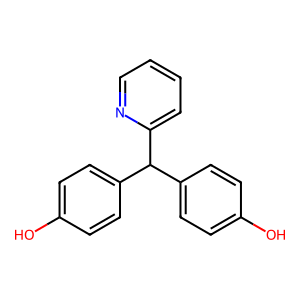

In [178]:
from rdkit import Chem
from rdkit.Chem import Draw

# Create molecule
mol = Chem.MolFromSmiles(df.iloc[92]["canon_smiles"])

img = Draw.MolToImage(mol)
# img.save("../img/mol8.png")
img

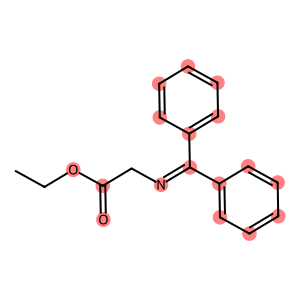

In [60]:
from rdkit import Chem
from rdkit.Chem.Draw import rdMolDraw2D

mol = Chem.MolFromSmiles(df.iloc[128]["canon_smiles"])

carbonyl = Chem.MolFromSmarts("OC(=O)")
nitrogen = Chem.MolFromSmarts("N=C")
benzene = Chem.MolFromSmarts("c1ccccc1")

matches1 = mol.GetSubstructMatches(carbonyl)
matches2 = mol.GetSubstructMatches(nitrogen)
matches3 = mol.GetSubstructMatches(benzene)

highlight_atoms = []
atom_colours = {}
for match in matches1:
    for atom in match:
        highlight_atoms.append(atom)
        atom_colours[atom] = (1,0,0)  # red

for match in matches2:
    for atom in match:
        highlight_atoms.append(atom)
        atom_colours[atom] = (0.0, 0.5, 0.8)  # blue

for match in matches3:
    for atom in match:
        highlight_atoms.append(atom)
        atom_colours[atom] = (1.0, 0.85, 0.0)  # yellow


# Bonds to highlight and their colors
highlight_bonds = []
bond_colors = {}

for bond in mol.GetBonds():
    a1 = bond.GetBeginAtomIdx()
    a2 = bond.GetEndAtomIdx()
    if a1 in atom_colours and a2 in atom_colours and atom_colours[a1] == atom_colours[a2]:
        highlight_bonds.append(bond.GetIdx())
        # Choose the color of one of the atoms, or mix them if you want
        bond_colors[bond.GetIdx()] = atom_colours[a1]

img = Draw.MolToImage(
    mol,
    highlightAtoms=highlight_atoms,
    highlightAtomColors=atom_colours
)

img

In [61]:
highlight_bonds

[2, 3, 6, 8, 9, 10, 11, 12, 14, 15, 16, 17, 18, 19, 20]

In [63]:
mol = Chem.MolFromSmiles(df.iloc[128]["canon_smiles"])

carbonyl = Chem.MolFromSmarts("OC(=O)")
nitrogen = Chem.MolFromSmarts("N=C")
benzene = Chem.MolFromSmarts("c1ccccc1")

matches1 = mol.GetSubstructMatch(carbonyl)
matches2 = mol.GetSubstructMatches(nitrogen)
matches3 = mol.GetSubstructMatches(benzene)

print(matches1)

bonds = []
for bond in mol.GetBonds():
    if bond.GetBeginAtomIdx() in matches1 and bond.GetEndAtomIdx() in matches1:
        bonds.append(bond.GetIdx())



drawer = rdMolDraw2D.MolDraw2DCairo(400, 300)
drawer.DrawMolecule(mol) #, highlightAtoms=highlight_atoms, highlightAtomColors=atom_colours, highlightBonds=highlight_bonds, highlightBondColors=bond_colors)
drawer.FinishDrawing()

png = drawer.GetDrawingText()
with open("molecule.png", "wb") as f:
    f.write(png)

(2, 3, 4)


In [ ]:
'[C:1]([C:2]([O:3][C:4](=[O:5])[C:6]([N:7]=[C:8]([c:9]1[c:10]([H:28])[c:11]([H:29])[c:12]([H:30])[c:13]([H:31])[c:14]1[H:32])[c:15]1[c:16]([H:33])[c:17]([H:34])[c:18]([H:35])[c:19]([H:36])[c:20]1[H:37])([H:26])[H:27])([H:24])[H:25])([H:21])([H:22])[H:23]'

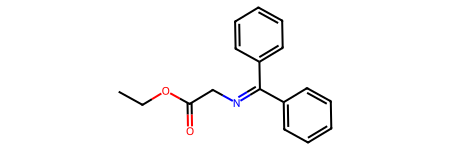

In [25]:
Chem.MolFromSmiles(df.iloc[50]["canon_smiles"])

In [31]:
df.iloc[587]

smiles                [O:1]([P:2]([O:3][H:42])(=[O:4])[C:5]([N:6]([C...
id                                                                 1539
energy                                                      -138.649438
atomization_energy                                             17.26368
homo_lumo_gap                                                  0.158157
                                            ...                        
fr_thiophene                                                          0
fr_unbrch_alkane                                                      6
fr_urea                                                               0
canon_smiles          O=P(O)(O)CN(CCCCCCN(CP(=O)(O)O)CP(=O)(O)O)CCCC...
solubility                                                    -0.087766
Name: 587, Length: 280, dtype: object

In [36]:
df[df["id"] == 769] #1539

,smiles,id,energy,atomization_energy,homo_lumo_gap,ionization_energy,electron_affinity,chemical_potential,molecular_dipole_norm,molecular_quadrupole_principal_invariant_2,...,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea,canon_smiles,solubility
868,[C:1]([C:2]([C:3]([O:4][C:5]([C:6]([C:7]([O:8]...,1795,-44.729896,6.389823,0.166185,0.485557,0.085122,-0.316758,0.816062,-144.535812,...,0,0,0,0,0,0,0,0,CCC(OCCCOC)OC(C)=O,-0.016848


In [39]:
y = df["solubility"]
X = df.drop(["solubility", "smiles", "canon_smiles", "id"], axis=1) # , "avg_atomic_quadrupole_principal_invariant_3", "molecular_quadrupole_principal_invariant_3"

In [41]:
X["Ipc"].max()

np.float64(2.172531166511117e+55)

In [28]:
X.iloc[179]["Ipc"]

np.float64(2.172531166511117e+55)

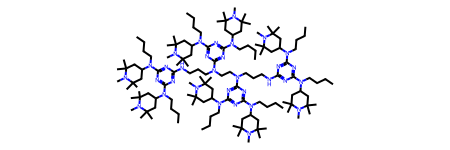

In [33]:
smiles = df.iloc[179]["canon_smiles"]
from rdkit import Chem
Chem.MolFromSmiles(smiles)

In [42]:
transformed_X = pd.DataFrame(pl[:-1].fit_transform(X), columns=X.columns)

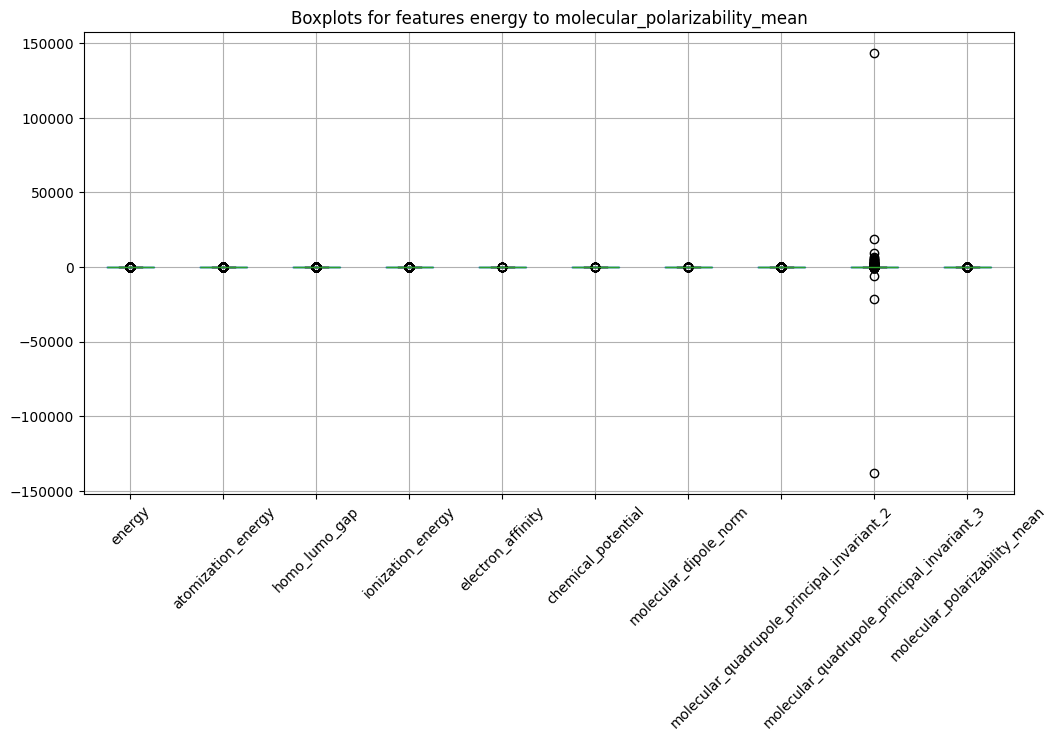

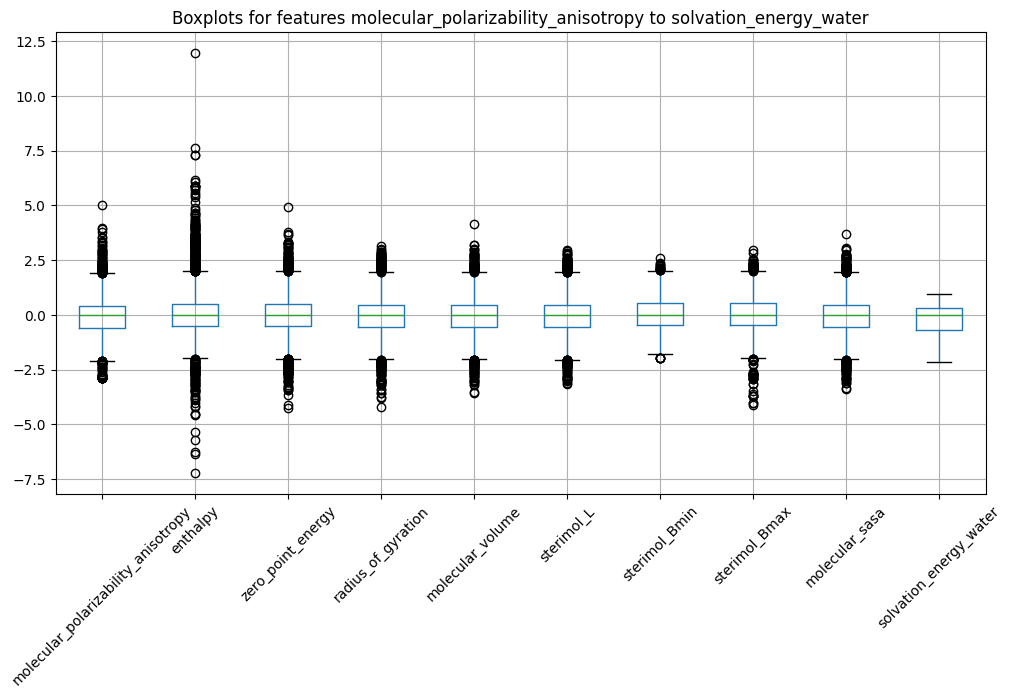

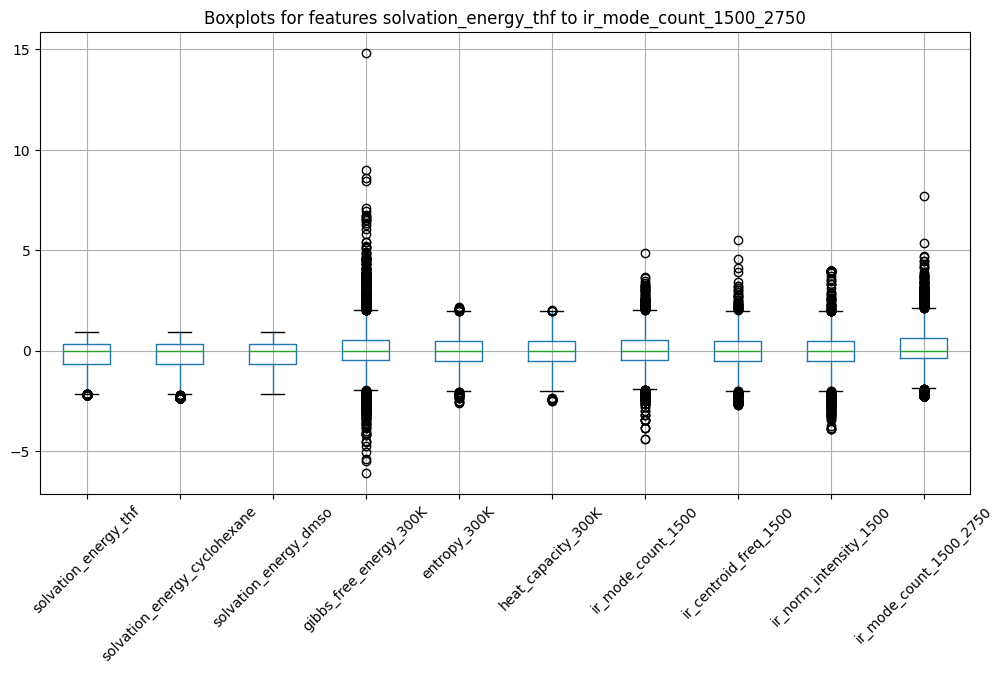

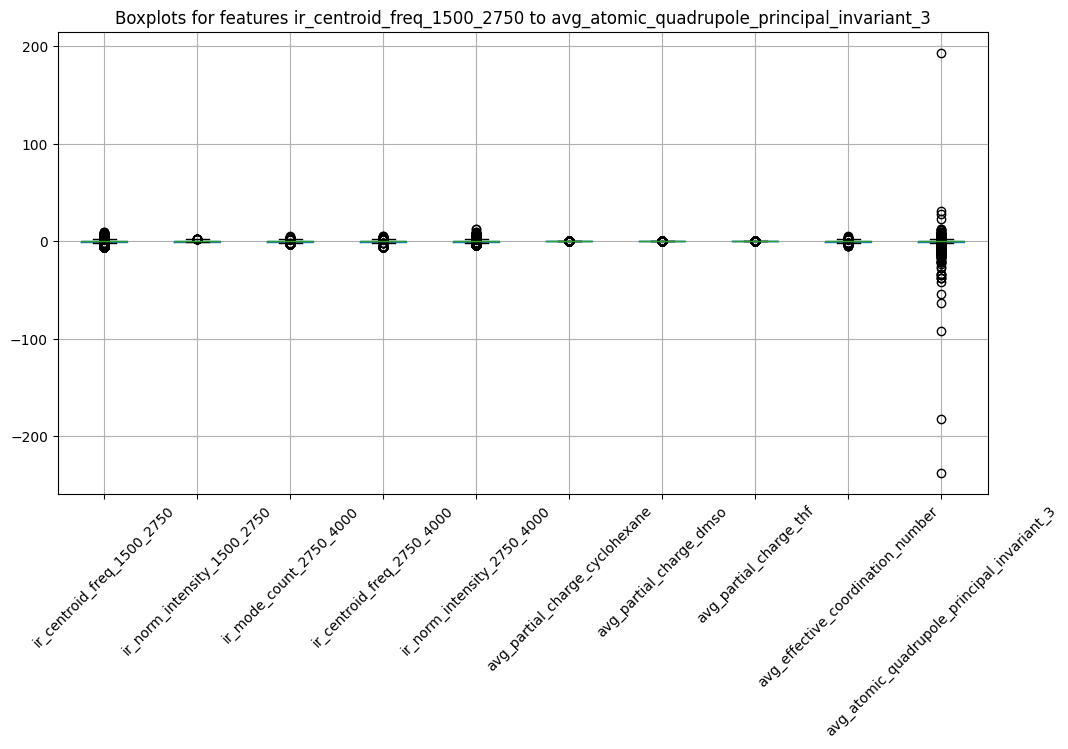

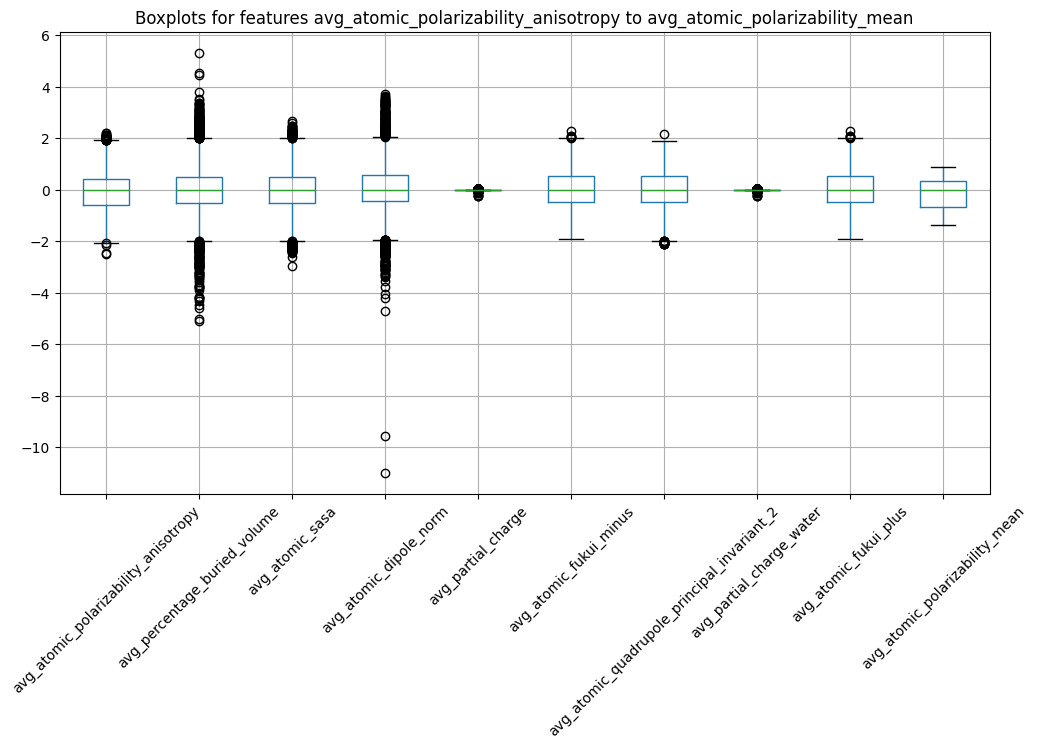

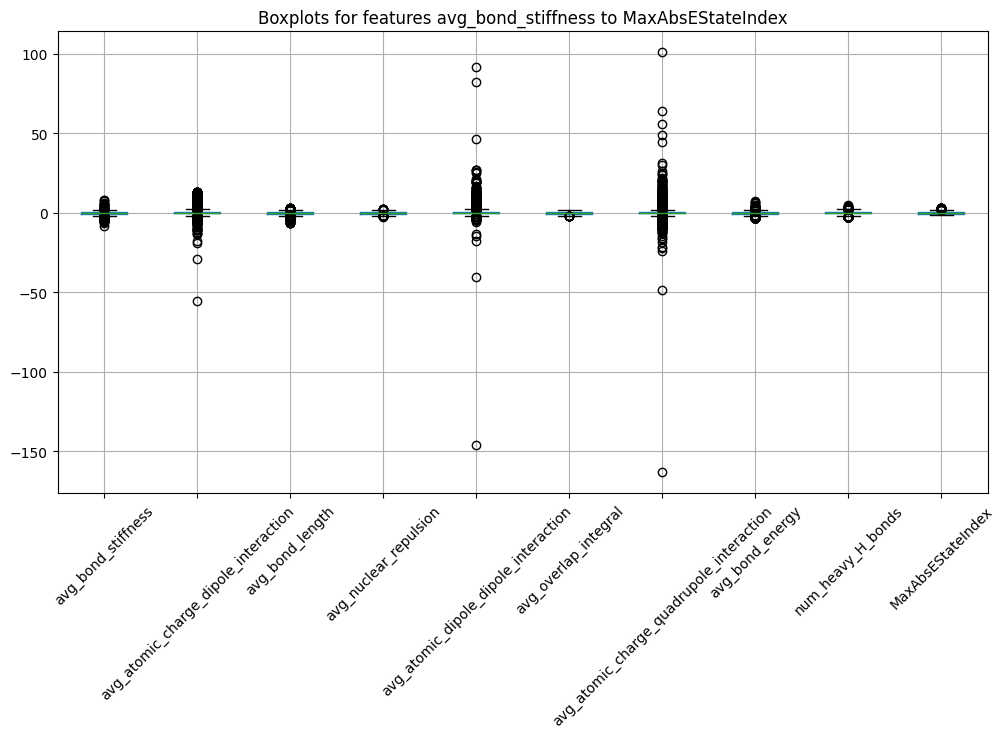

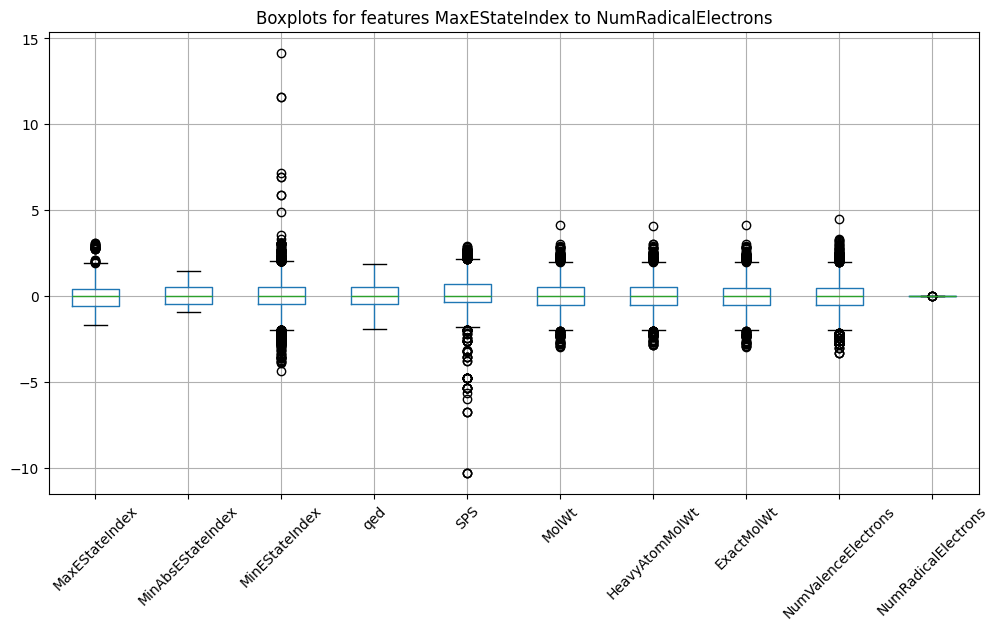

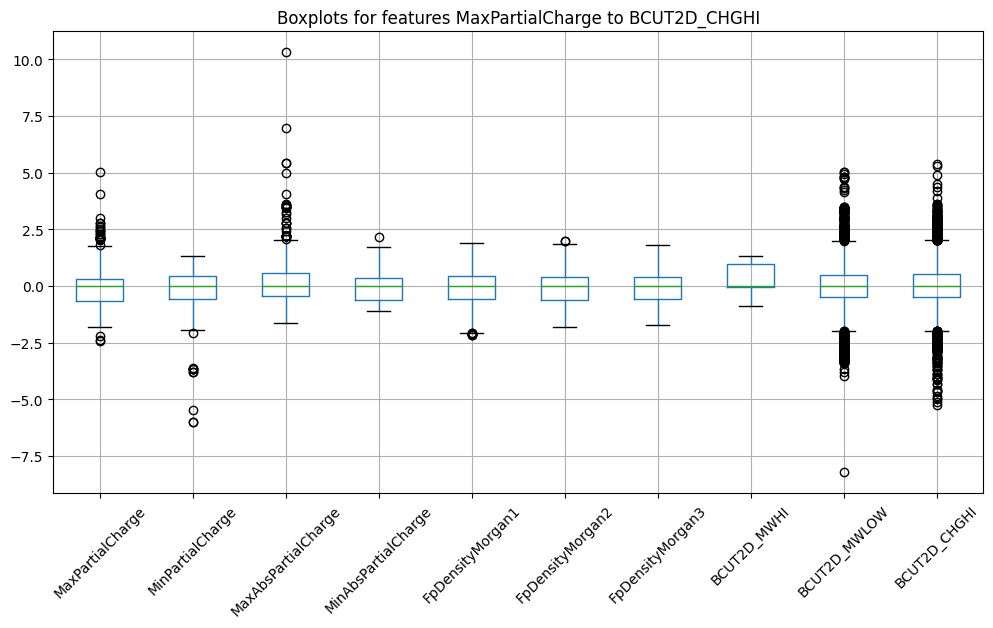

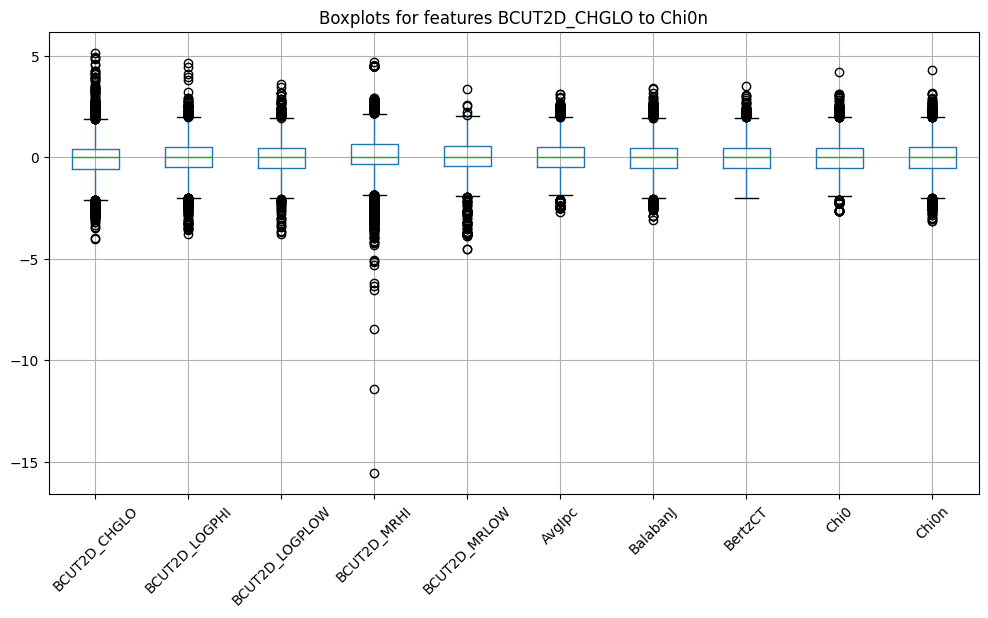

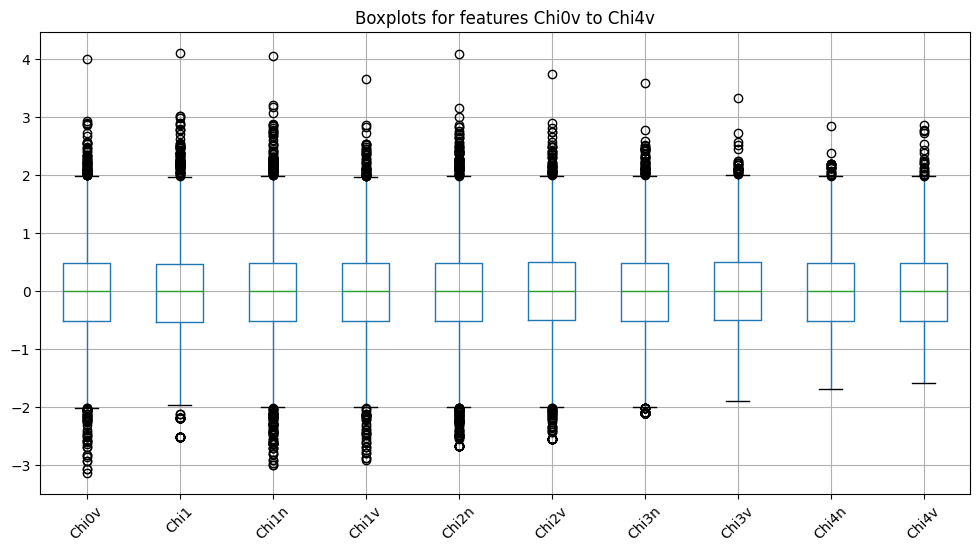

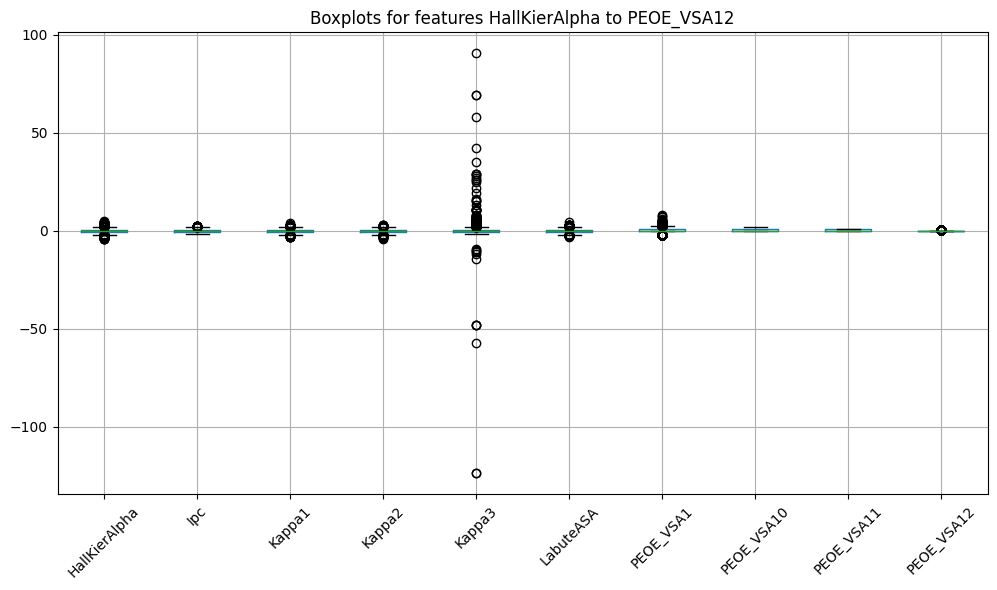

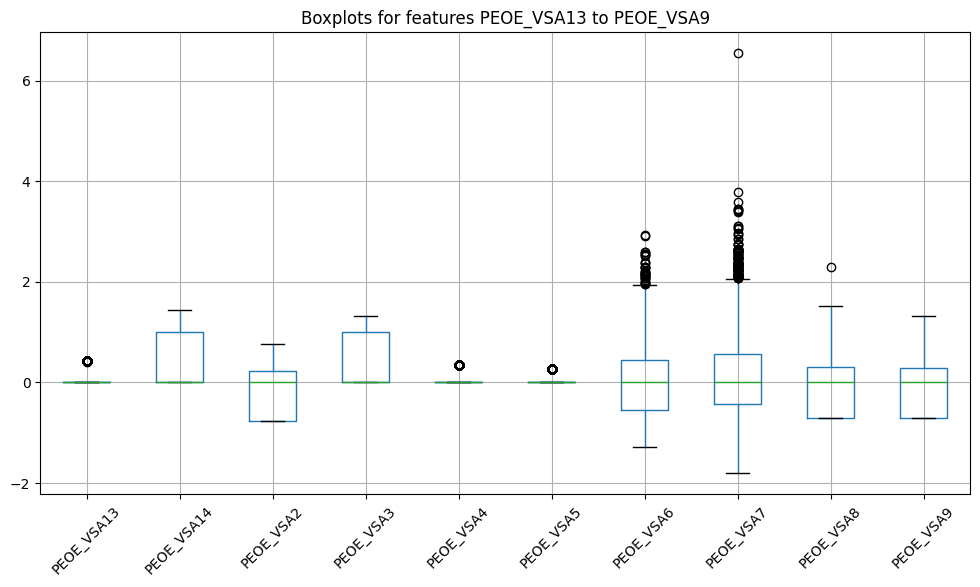

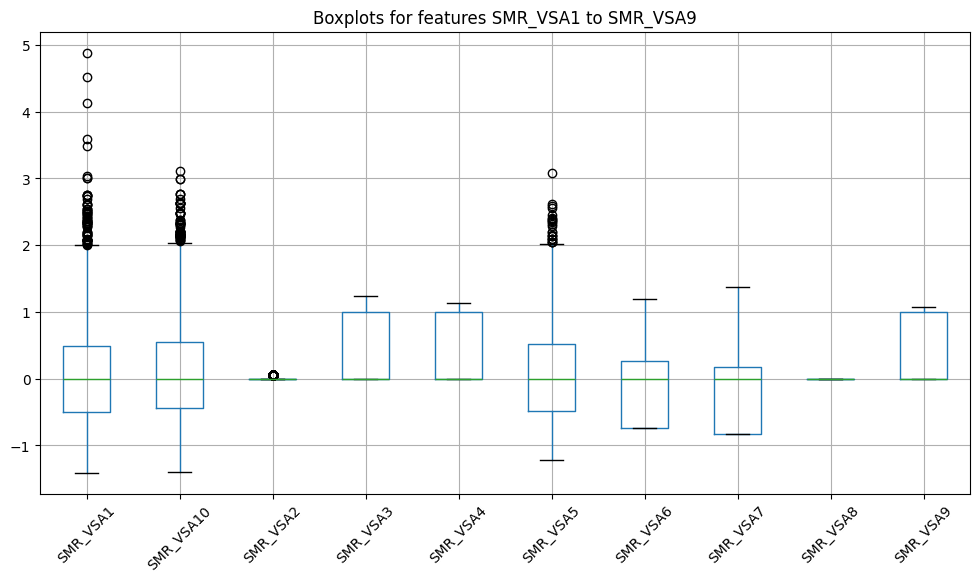

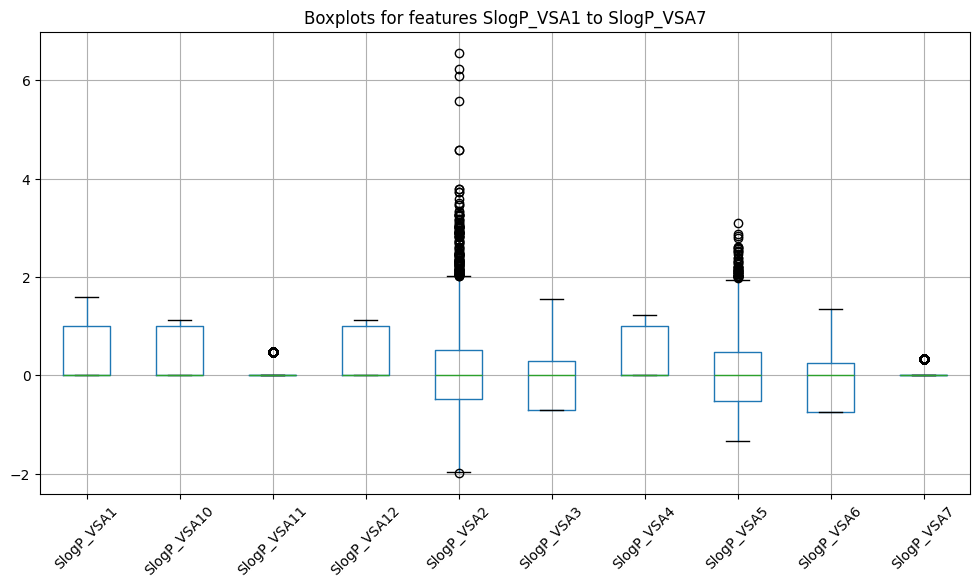

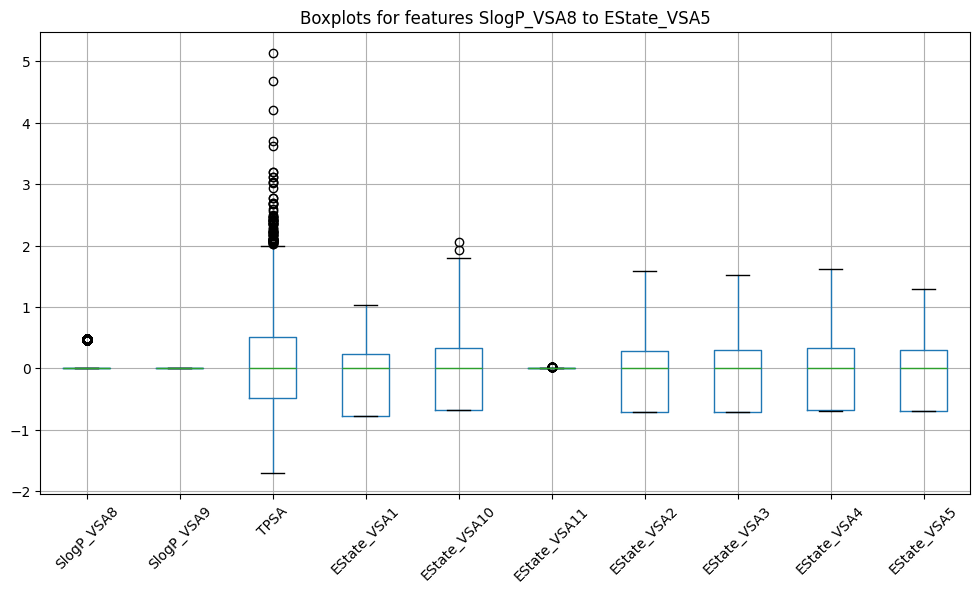

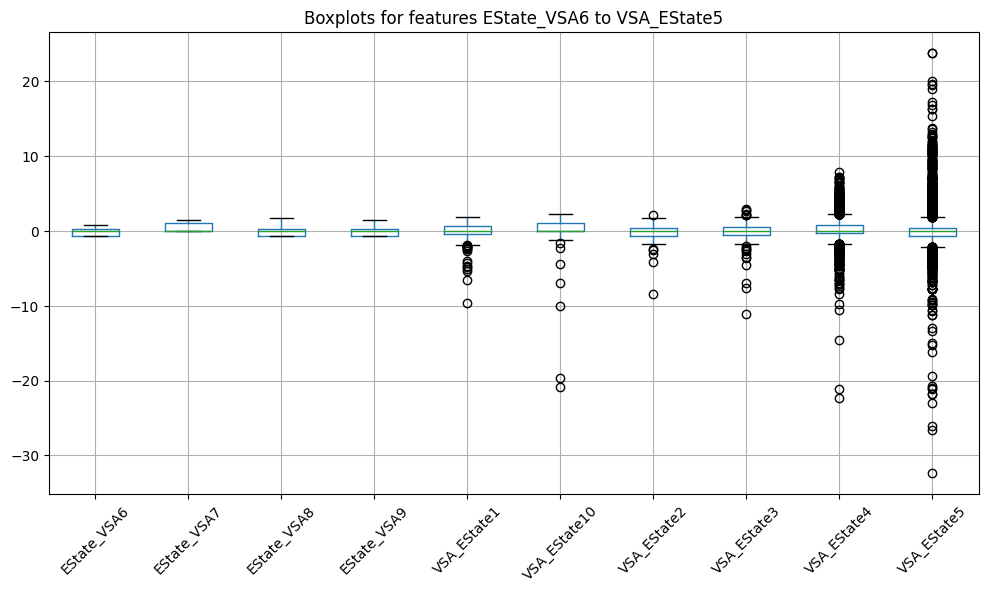

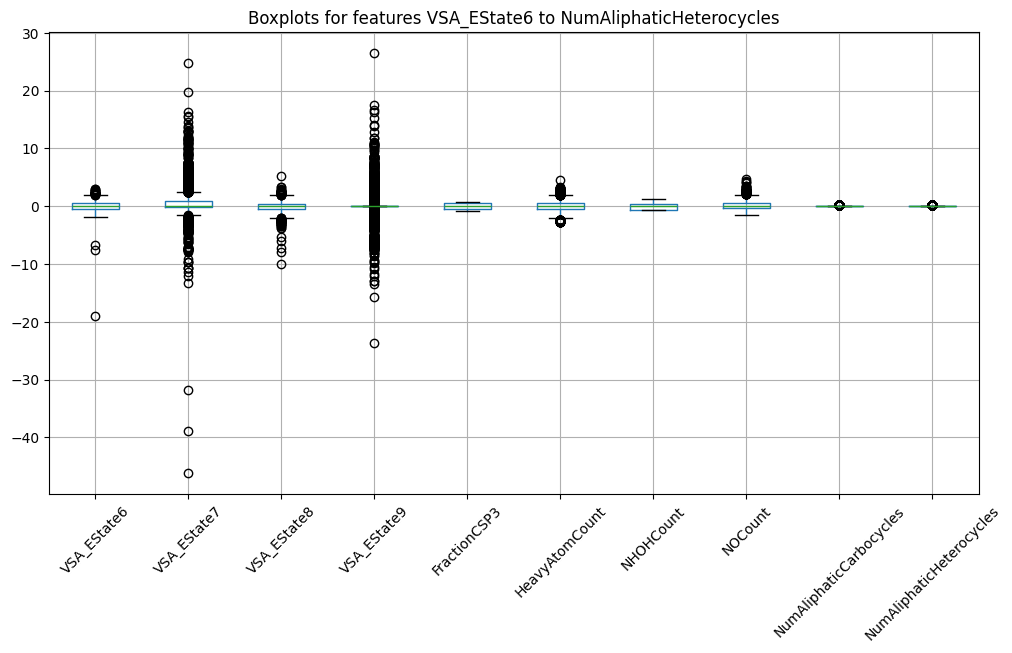

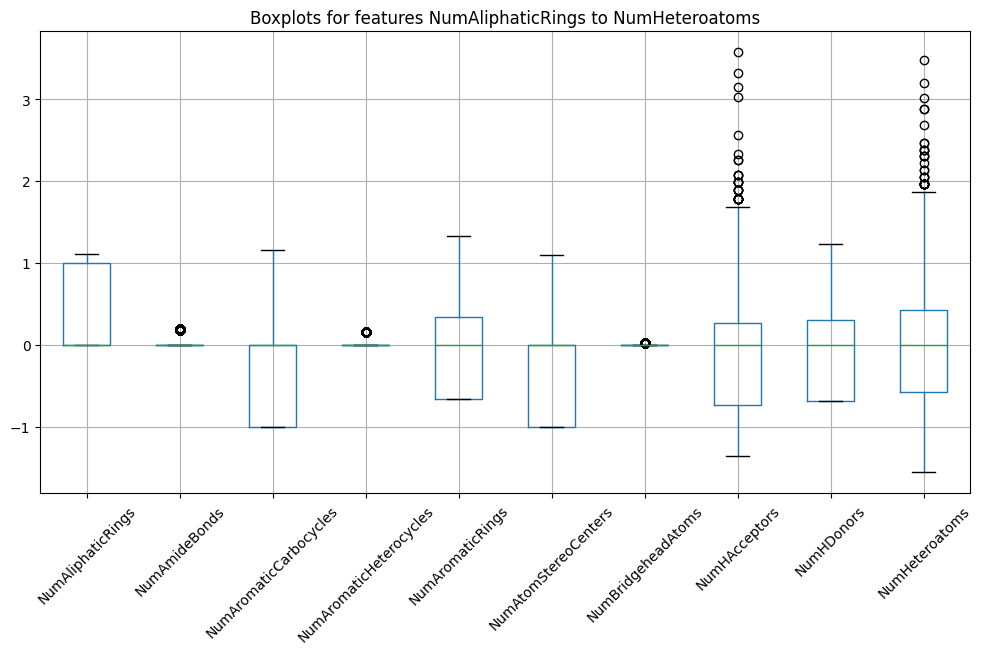

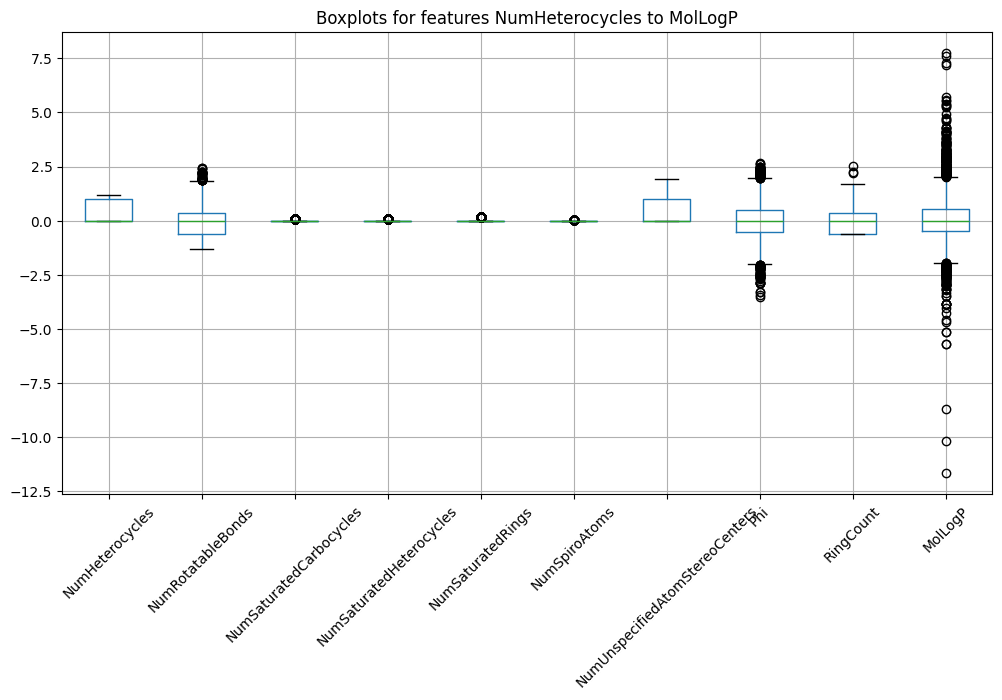

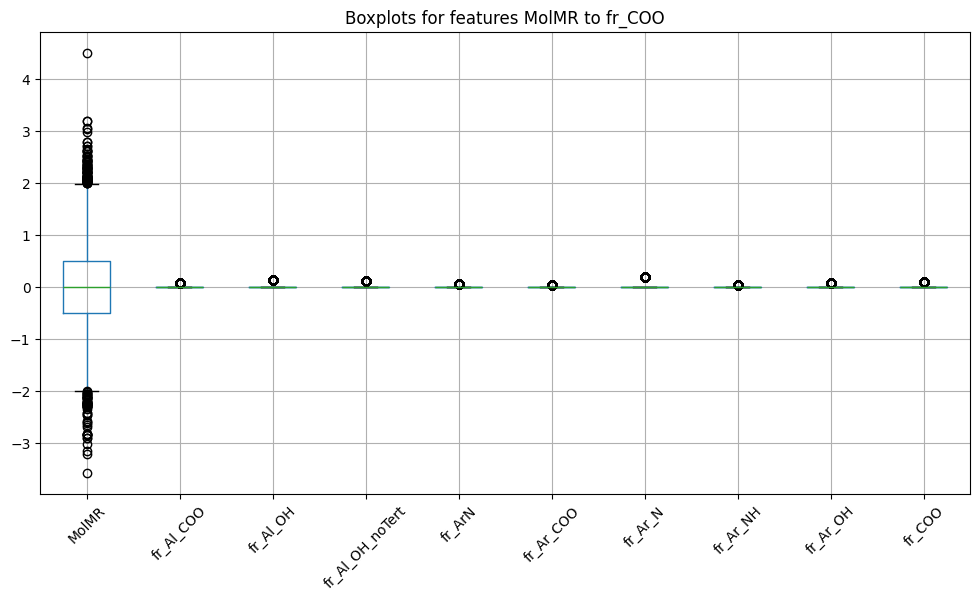

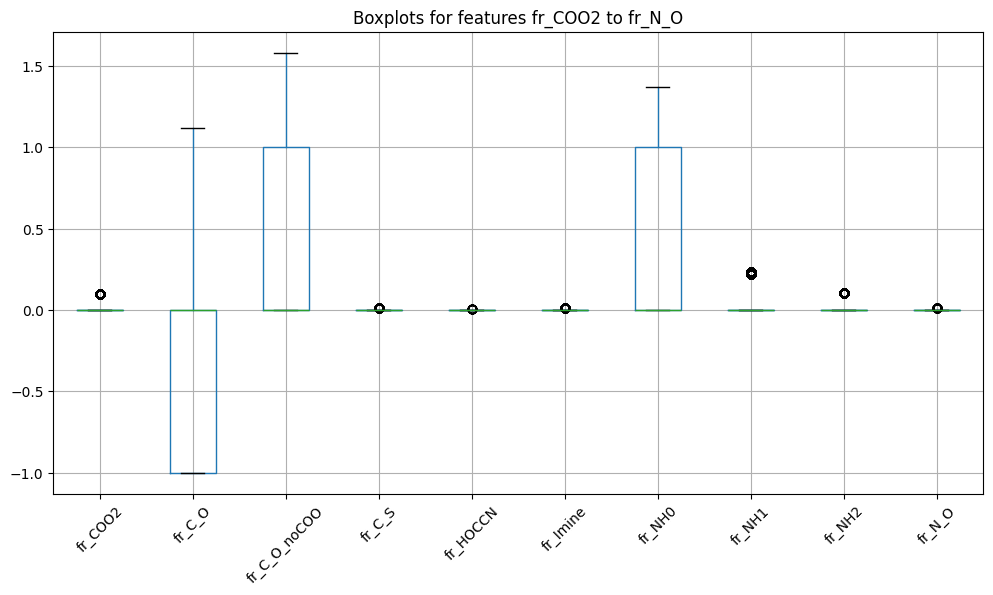

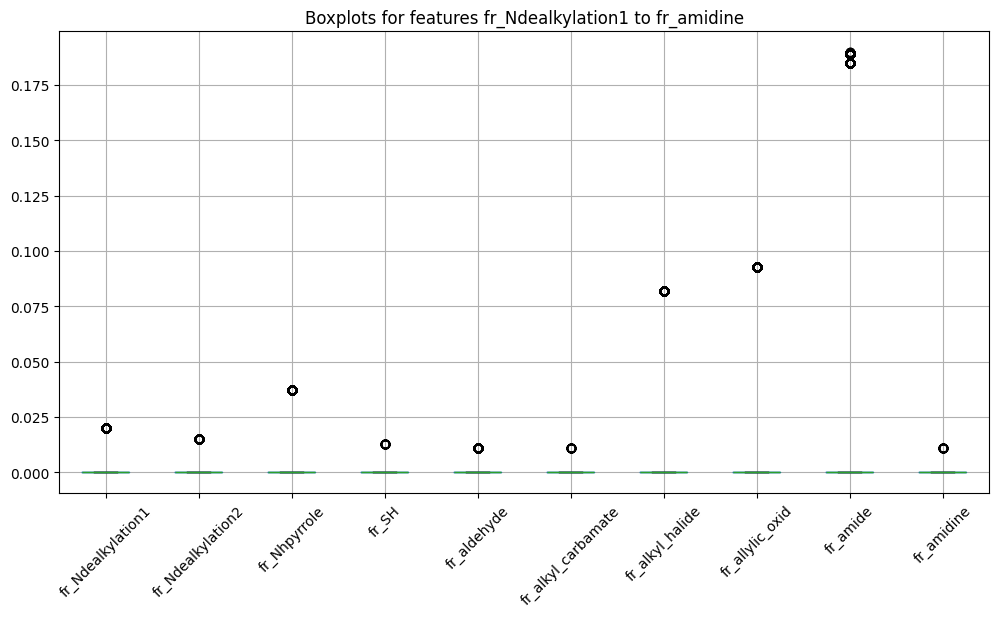

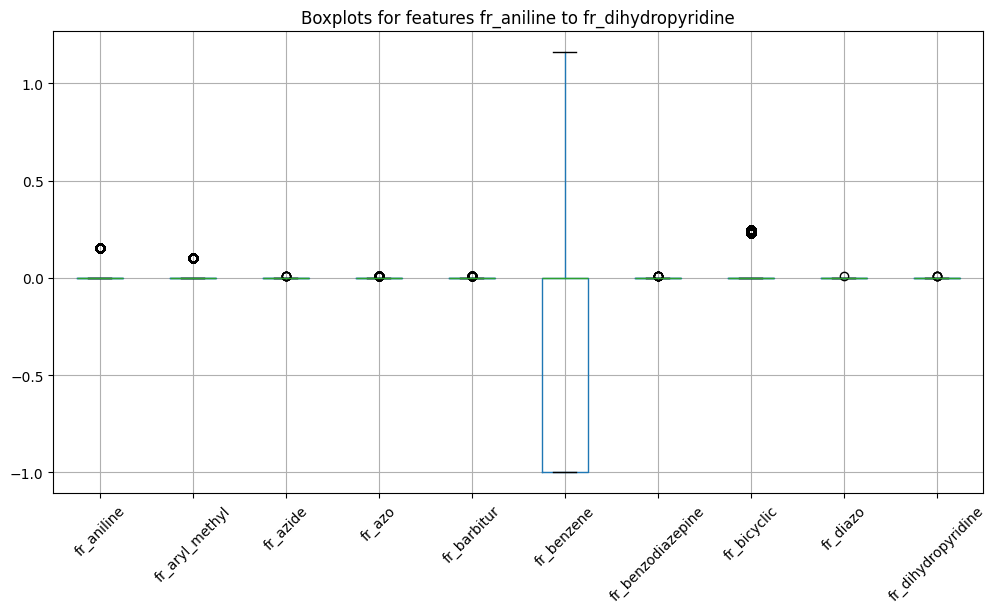

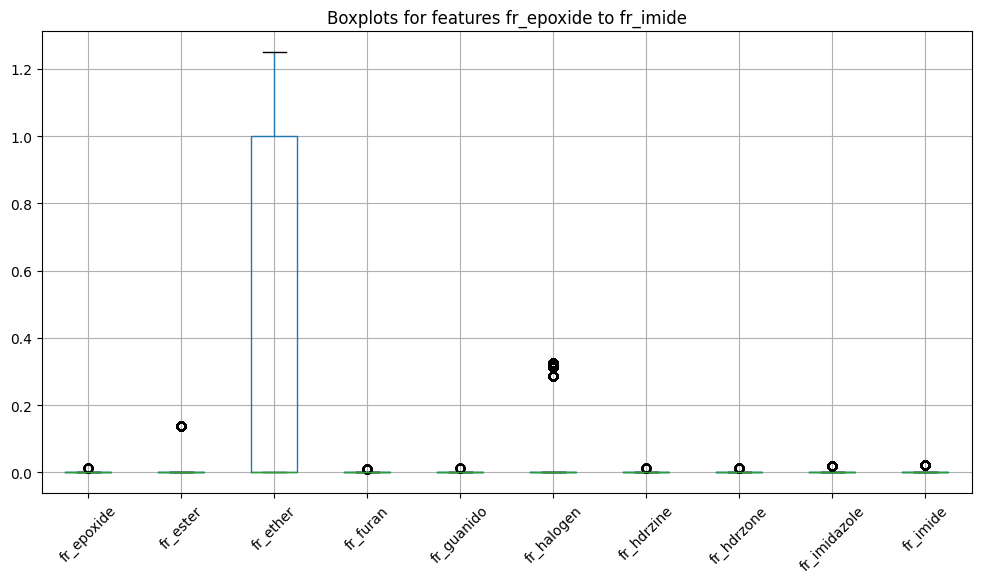

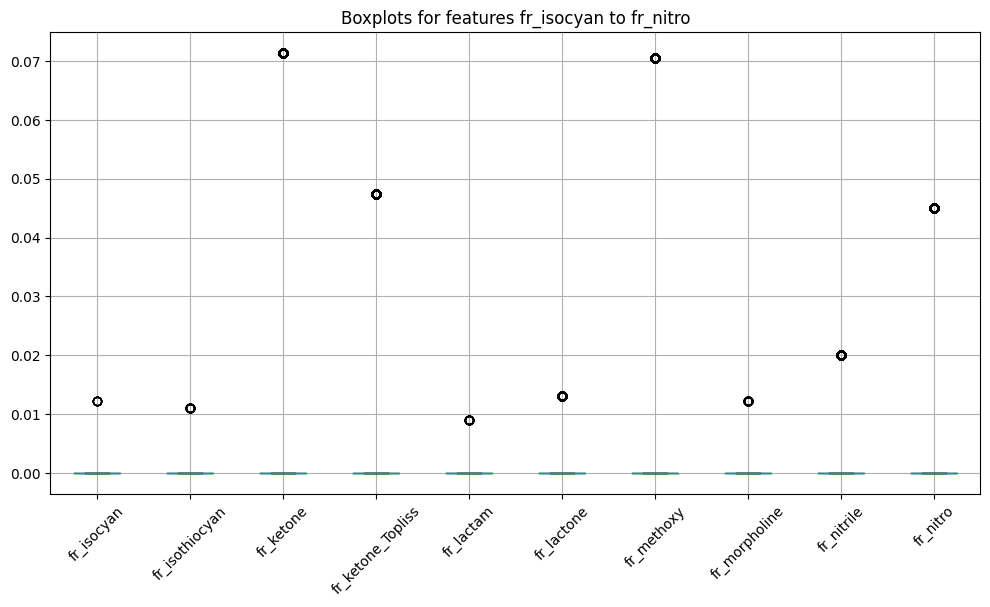

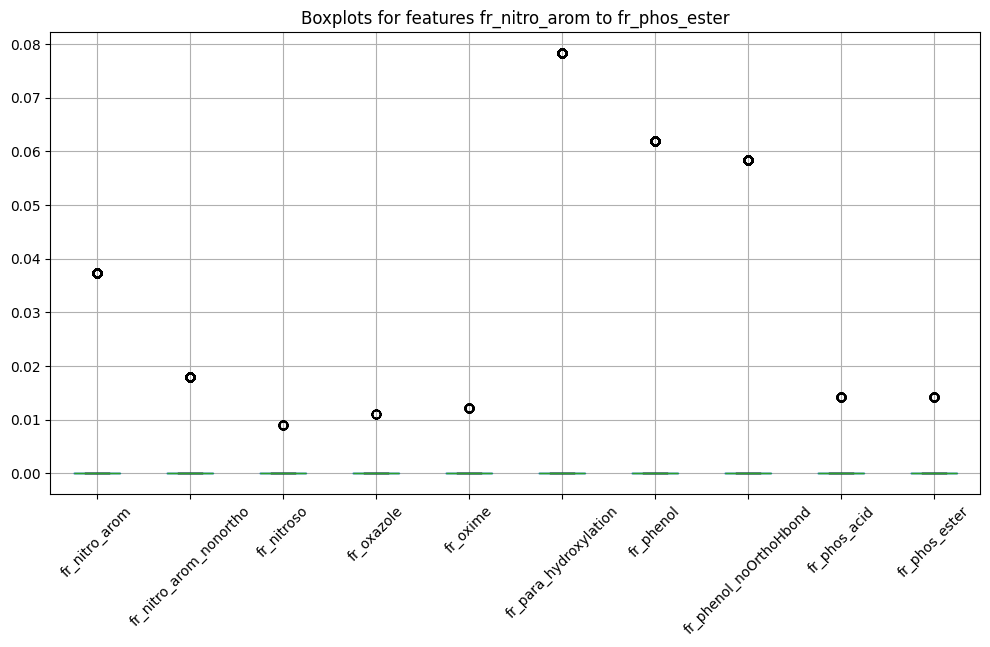

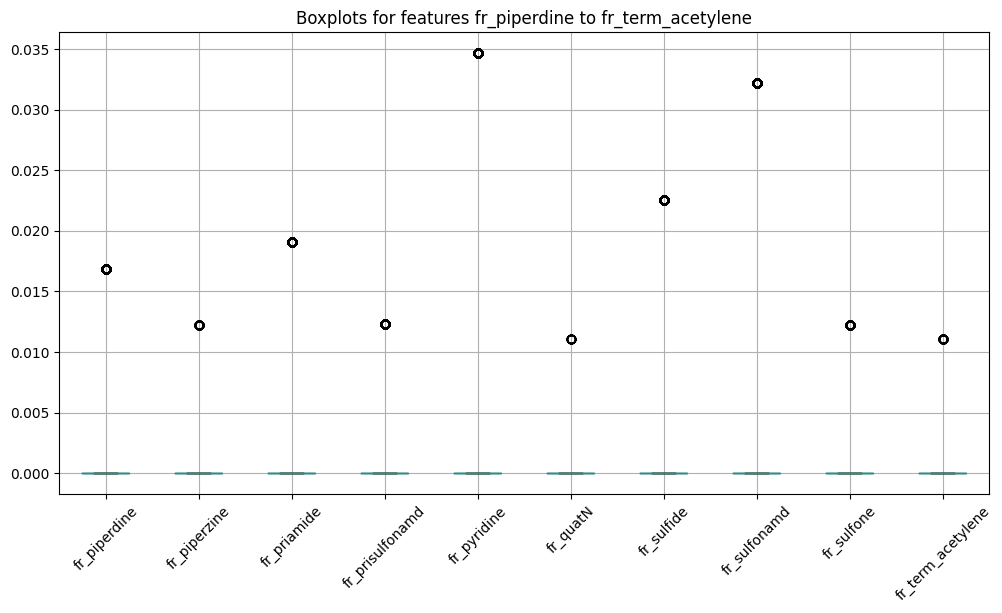

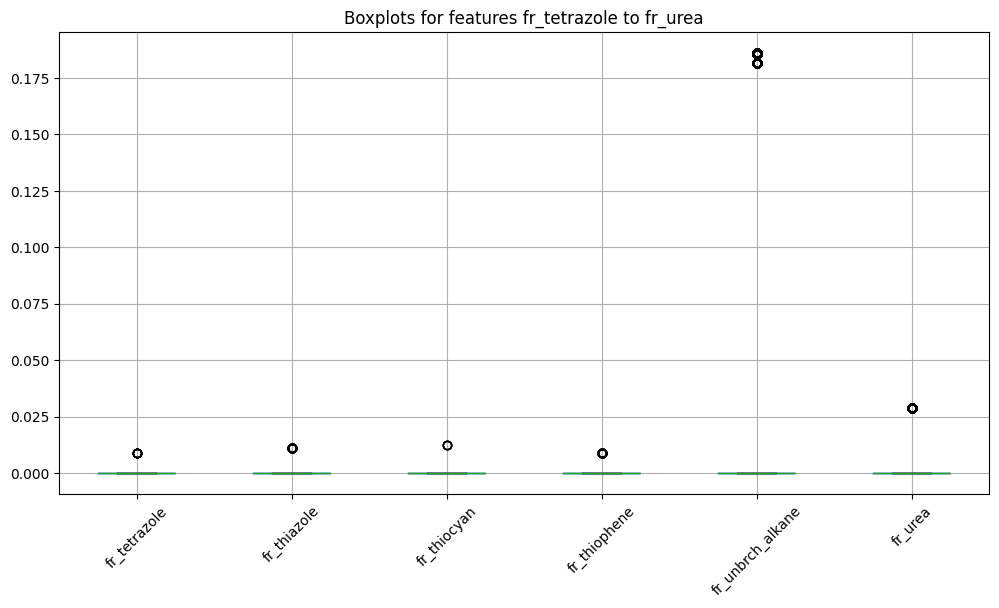

In [ ]:
# Group features into chunks of 10
feature_groups = [transformed_X.columns[i:i+10] for i in range(0, len(transformed_X.columns), 10)]

for i, group in enumerate(feature_groups, 1):
    plt.figure(figsize=(12,6))
    transformed_X[group].boxplot()
    plt.title(f'Boxplots for features {group[0]} to {group[-1]}')
    plt.xticks(rotation=45)
    plt.show()

In [22]:
X = X.drop([7359]) # , 587

In [15]:
X_wo_atom = X.drop(["avg_atomic_quadrupole_principal_invariant_3"], axis=1)

In [9]:
df[["id", "avg_atomic_quadrupole_principal_invariant_3"]].nlargest(10, columns="avg_atomic_quadrupole_principal_invariant_3")

,id,avg_atomic_quadrupole_principal_invariant_3
7359,769,14.471934
5357,5884,0.230704
8171,842,0.200549
1825,2685,0.156272
1826,2686,0.079830
5993,6456,0.077964
7172,7520,0.075170
3661,4347,0.071856
1406,2289,0.069148
2841,3603,0.060347


In [10]:
df[["id", "molecular_quadrupole_principal_invariant_3"]].nlargest(10, columns="molecular_quadrupole_principal_invariant_3")

,id,molecular_quadrupole_principal_invariant_3
587,1539,1.561343e+09
1657,2529,1.543235e+08
3949,4610,7.055779e+07
96,1088,4.600046e+07
6969,7337,4.160781e+07
1590,2465,3.977570e+07
2999,3748,3.447213e+07
2997,3746,3.447213e+07
7001,7367,3.429472e+07
7012,7376,2.534992e+07


In [18]:
columns = X.columns.to_numpy()
batches = np.array_split(columns, 28)

In [27]:
X[batches[0]].boxplot()
plt.plot()

[]

In [ ]:
plt.plot()

ValueError: Could not find plotting backend 'molecular_polarizability_mean'. Ensure that you've installed the package providing the 'molecular_polarizability_mean' entrypoint, or that the package has a top-level `.plot` method.

KeyError: "None of [Index([('energy', 'atomization_energy', 'homo_lumo_gap', 'ionization_energy', 'electron_affinity', 'chemical_potential', 'molecular_dipole_norm', 'molecular_quadrupole_principal_invariant_2', 'molecular_quadrupole_principal_invariant_3', 'molecular_polarizability_mean')], dtype='object')] are in the [columns]"

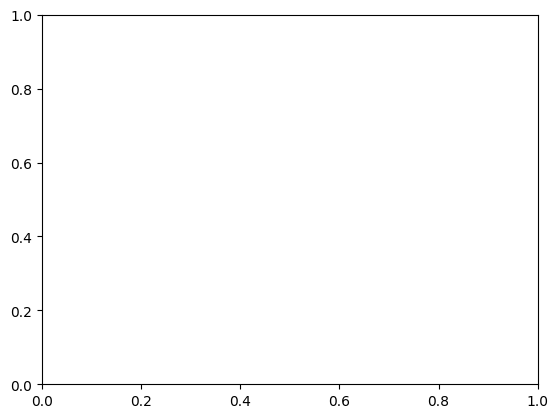

In [19]:
for batch in batches:
    X.boxplot(batch)

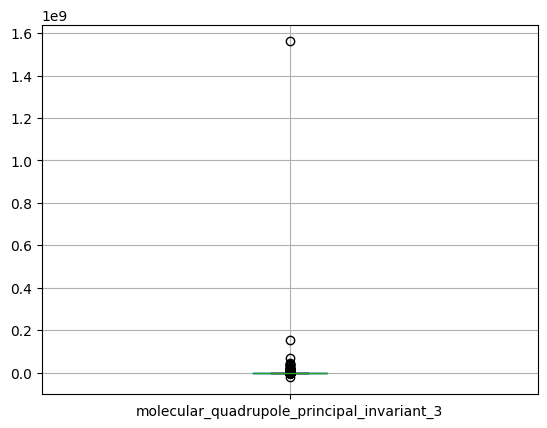

In [ ]:

X.boxplot("molecular_quadrupole_principal_invariant_3")
plt.show()

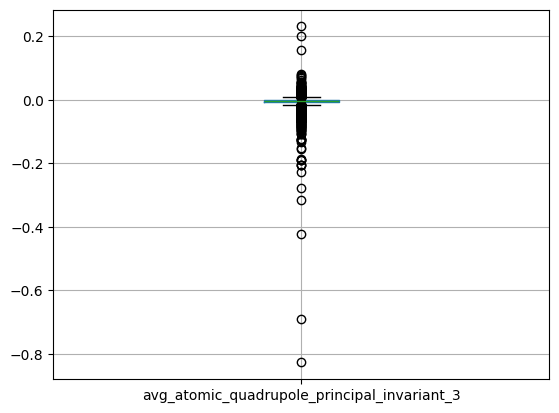

In [ ]:
X.boxplot("avg_atomic_quadrupole_principal_invariant_3")
plt.show()

In [ ]:
from time import sleep

for column in X.columns:
    X.boxplot(column)
    plt.plot()
    sleep(5)

In [19]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)
pl = make_pipeline(sklearn.linear_model.LinearRegression())

In [28]:
for i, (train_idx, test_idx) in enumerate(cv.split(X)):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    
    pl.fit(X_train, y_train)
    y_pred = pl.predict(X_test)

    
    print(f"Fold {i+1} R²:", r2_score(y_test, y_pred))

    coefs = pl["predict"].coef_

    sort = np.argsort(np.abs(coefs))
    
    for coef, feature in zip(coefs[sort[::-1]], df.columns[sort[::-1]], strict=True):
        print(feature, coef)
    
    print("\n\n")

Fold 1 R²: 0.7383942624622595
avg_atomic_quadrupole_principal_invariant_2 -3828007.9428481585
avg_atomic_dipole_norm 3828006.025198895
avg_atomic_sasa 2455.264884447019
avg_partial_charge_cyclohexane -1728.5392120891781
ir_norm_intensity_2750_4000 -1510.788674897114
avg_atomic_fukui_minus 388.7909466023875
ir_centroid_freq_2750_4000 376.8388608826351
fr_bicyclic 190.12068580215416
fr_tetrazole 139.50319116910072
fr_aryl_methyl -134.2753870164256
fr_barbitur 128.5398182174875
fr_Ndealkylation2 102.25128848538674
fr_nitro_arom -90.06121330034145
fr_halogen -80.70819273377272
fr_aniline 75.41103256645653
fr_sulfone 63.46127963364275
EState_VSA1 -62.632475922922566
fr_sulfonamd -59.64882179934294
fr_prisulfonamd 53.02449130383485
solvation_energy_thf 49.60273263348593
fr_imide -46.823874174811024
fr_lactone 41.615953474282584
sterimol_Bmax -39.6625522186893
fr_piperdine -36.73482760504401
fr_sulfide -34.10400748068519
fr_C_O_noCOO 34.04611746936594
fr_C_S -33.99041300135615
fr_imidazole -3

In [ ]:
minidx = X_transformed["avg_atomic_quadrupole_principal_invariant_3"].argmin()
maxidx = X_transformed["avg_atomic_quadrupole_principal_invariant_3"].argmax()

In [ ]:
smiles = df.iloc[[minidx, maxidx]]["canon_smiles"].values

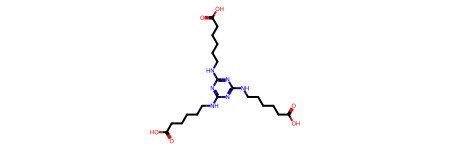

In [ ]:
Chem.MolFromSmiles(smiles[0])

In [ ]:
smiles2 = df.iloc[[587, 1657, 8704]]["canon_smiles"].values

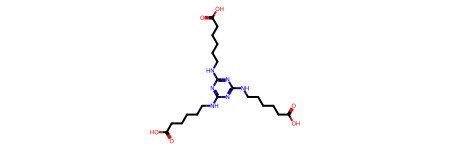

In [ ]:
Chem.MolFromSmiles(smiles2[2])

In [ ]:
df[["id", "molecular_quadrupole_principal_invariant_3"]].nsmallest(10, columns="molecular_quadrupole_principal_invariant_3")

,id,molecular_quadrupole_principal_invariant_3
8704,944,-2.265102e+07
1910,2762,-4.220389e+06
1721,2590,-1.356274e+06
1601,2476,-2.732290e+05
4094,4741,-2.037881e+05
1532,2408,-1.800906e+05
2695,3471,-1.706490e+05
425,1391,-1.571091e+05
371,1341,-1.510300e+05
1448,2327,-1.020005e+05


In [ ]:
feature = df["avg_atomic_quadrupole_principal_invariant_3"]
# feature = df["molecular_quadrupole_principal_invariant_3"]

Q1 = feature.quantile(0.25)
Q3 = feature.quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = feature[(feature < lower) | (feature > upper)]

print(len(outliers))

594


In [ ]:
X_test = X_transformed.drop([maxidx, minidx])

<Axes: >

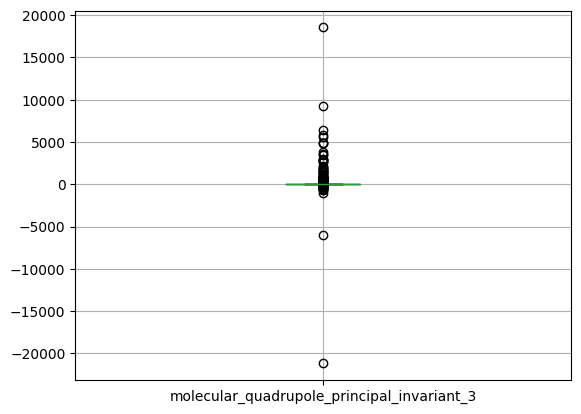

In [ ]:
X_test.boxplot("molecular_quadrupole_principal_invariant_3")

<Axes: >

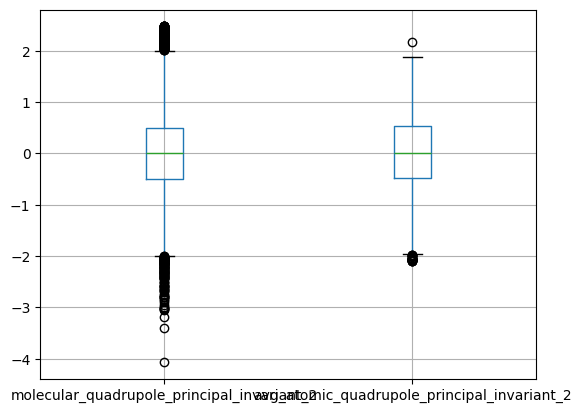

In [ ]:
X_transformed[["molecular_quadrupole_principal_invariant_2", "avg_atomic_quadrupole_principal_invariant_2"]].boxplot()

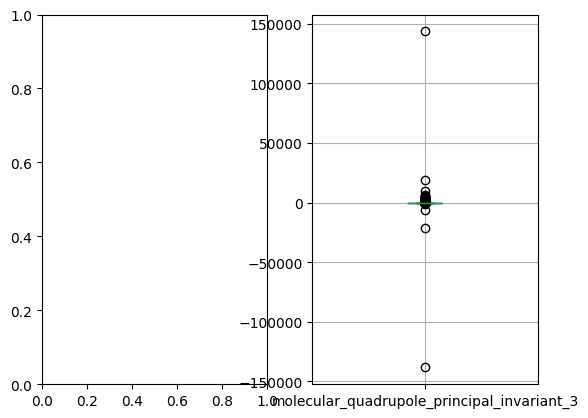

In [ ]:
fig, ax = plt.subplots(1, 2)

ax[0] = X_transformed.boxplot("molecular_quadrupole_principal_invariant_3")

# ax[0].boxplot(X_transformed["molecular_quadrupole_principal_invariant_2"])

# ax[1].boxplot(X_transformed["avg_atomic_quadrupole_principal_invariant_2"])

plt.show()

In [ ]:
def boxplots(df):
    # Group features into chunks of 10
    feature_groups = [df.columns[i:i+10] for i in range(0, len(df.columns), 10)]

    for i, group in enumerate(feature_groups, 1):
        plt.figure(figsize=(12,6))
        df[group].boxplot()
        plt.title(f'Boxplots for features {group[0]} to {group[-1]}')
        plt.xticks(rotation=45)
        plt.show()

In [ ]:
X_test = X_transformed.drop(["molecular_quadrupole_principal_invariant_3", "avg_atomic_quadrupole_principal_invariant_2", "avg_atomic_quadrupole_principal_invariant_3"], axis=1)

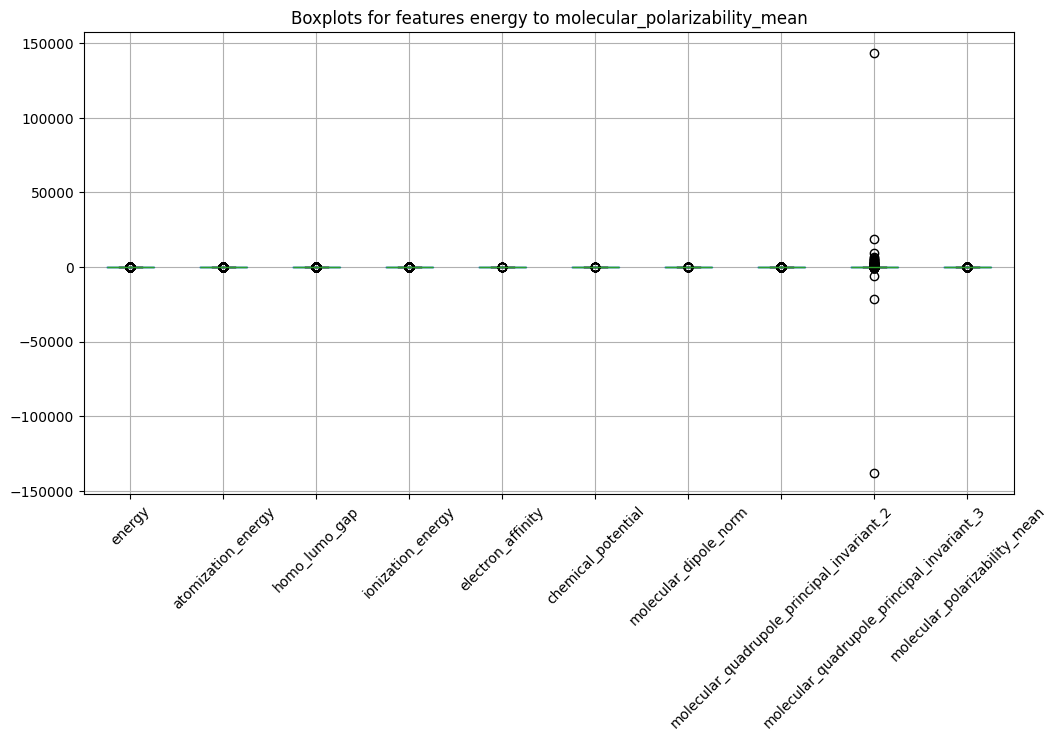

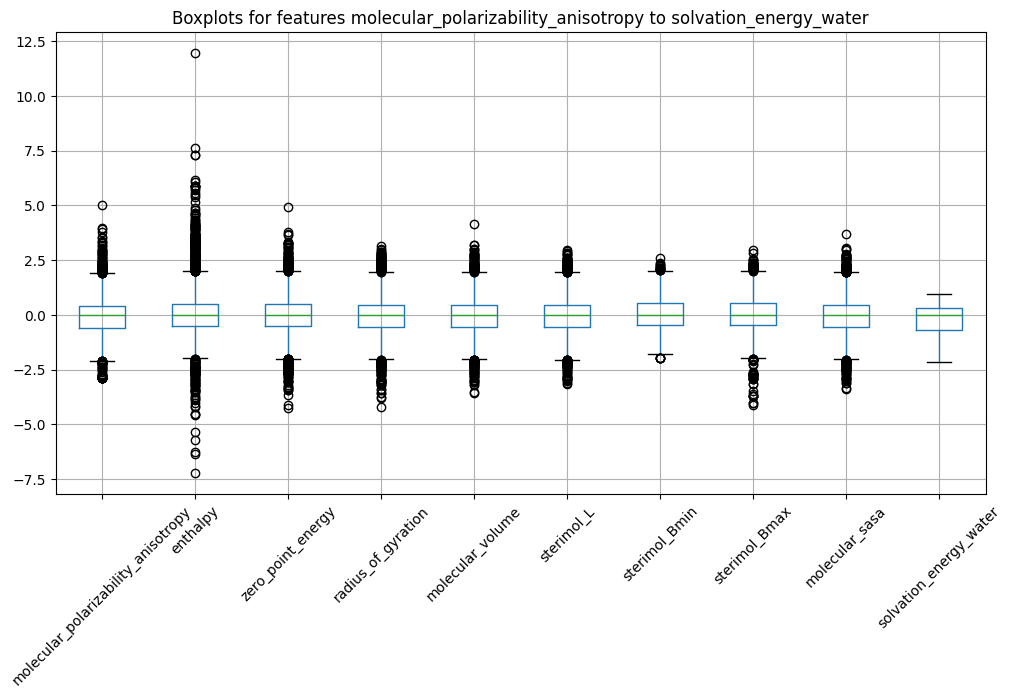

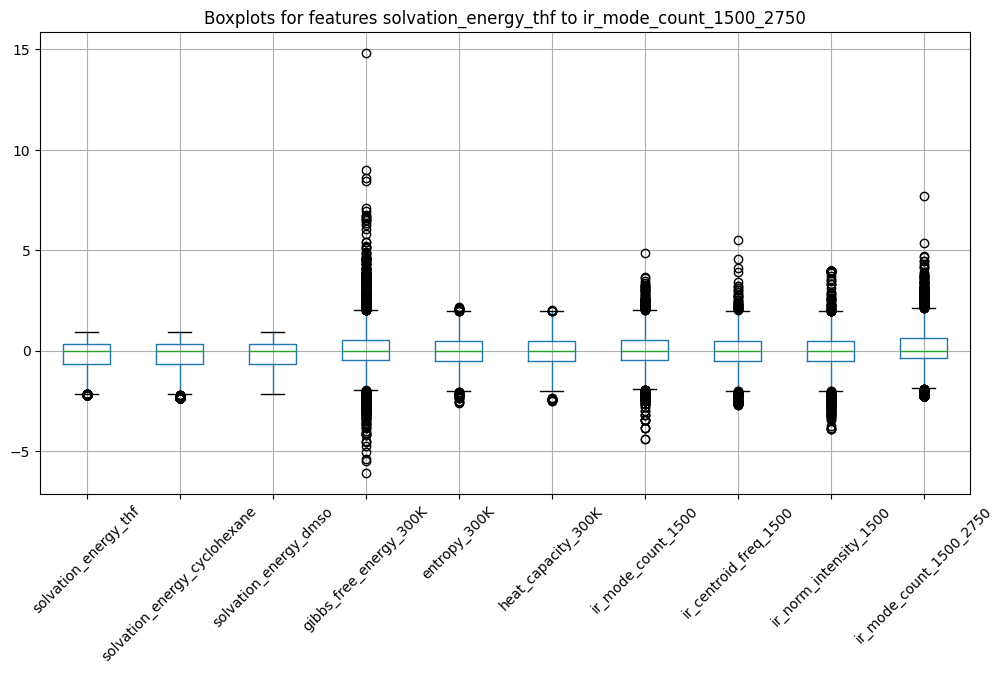

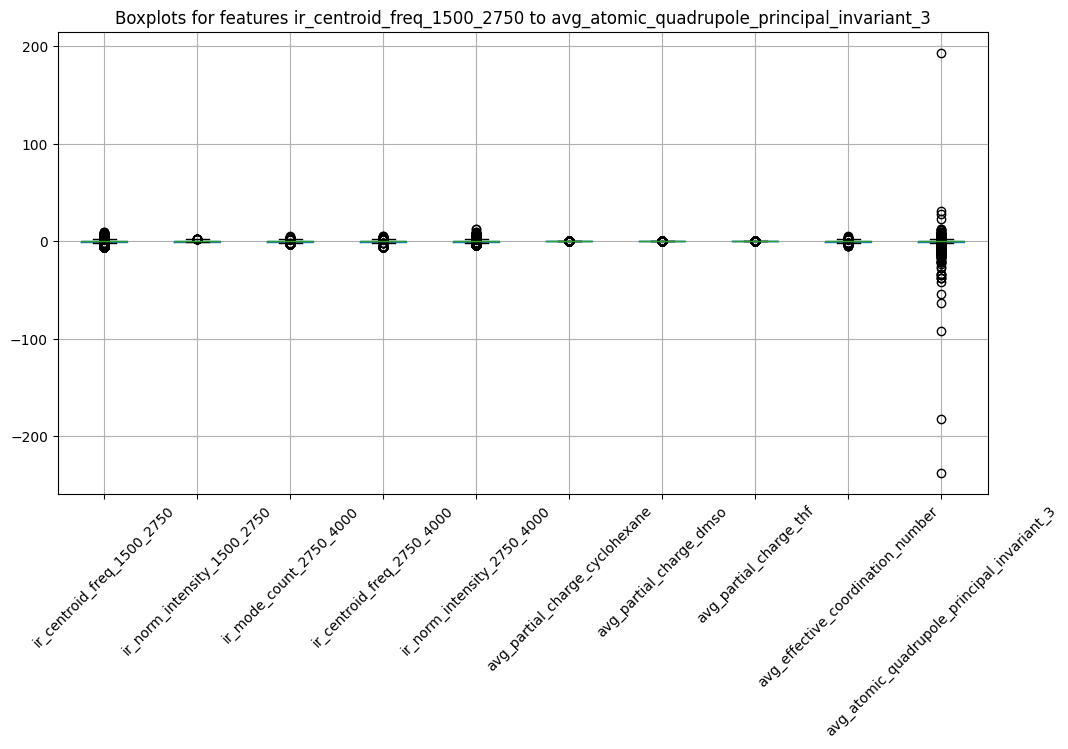

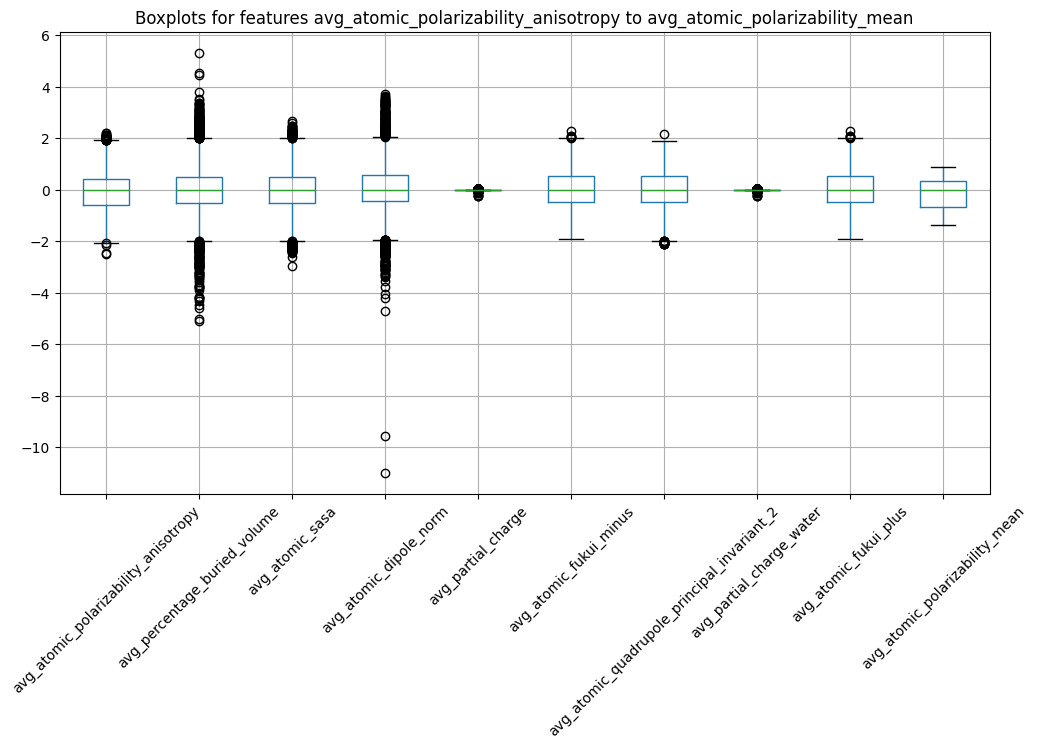

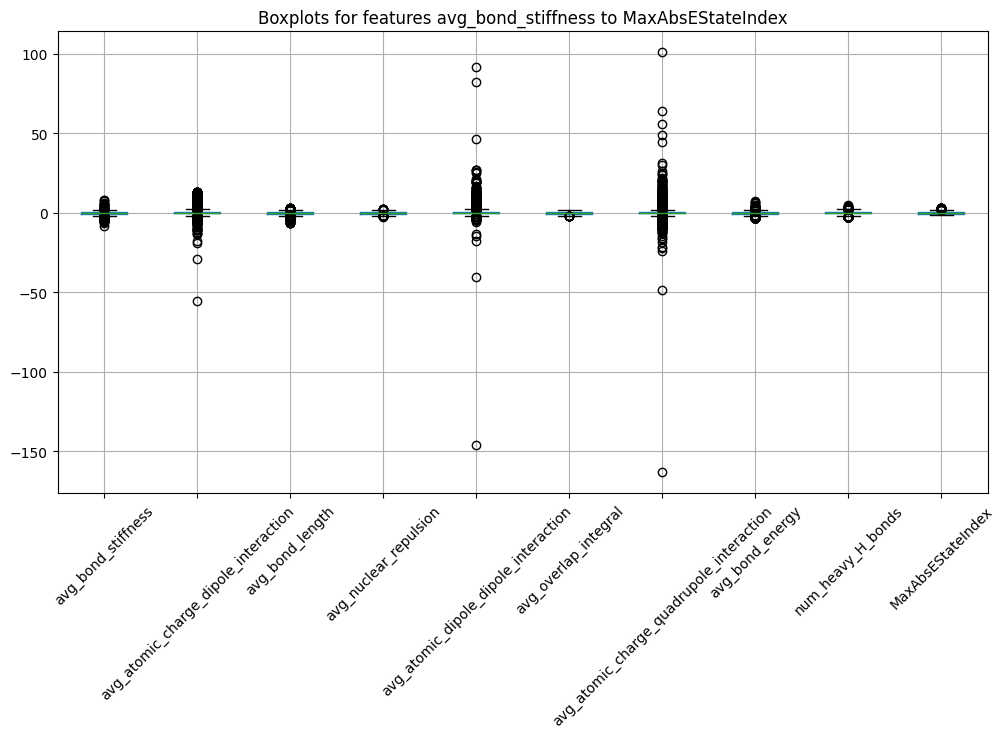

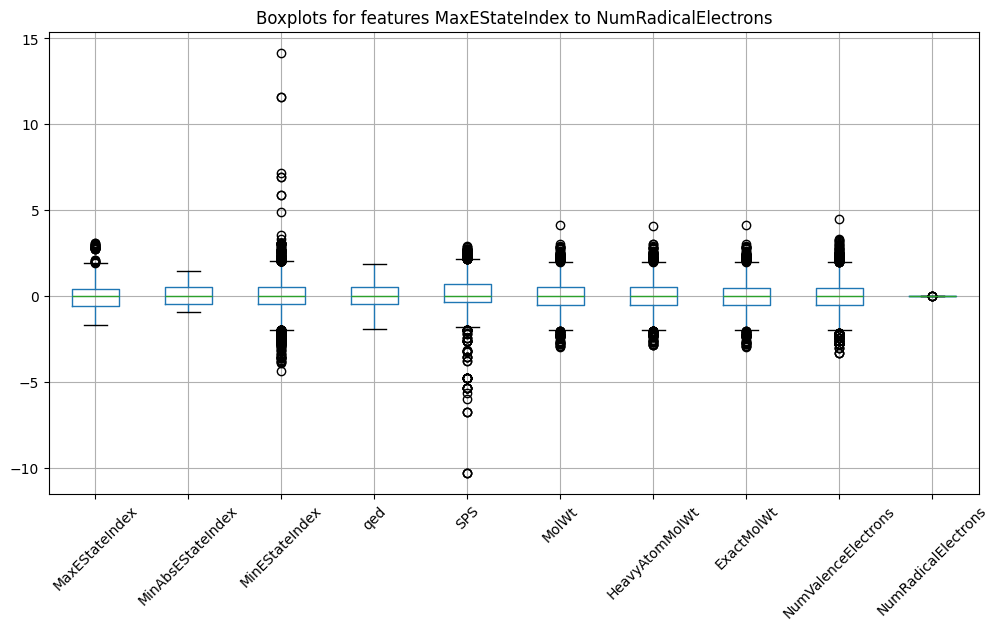

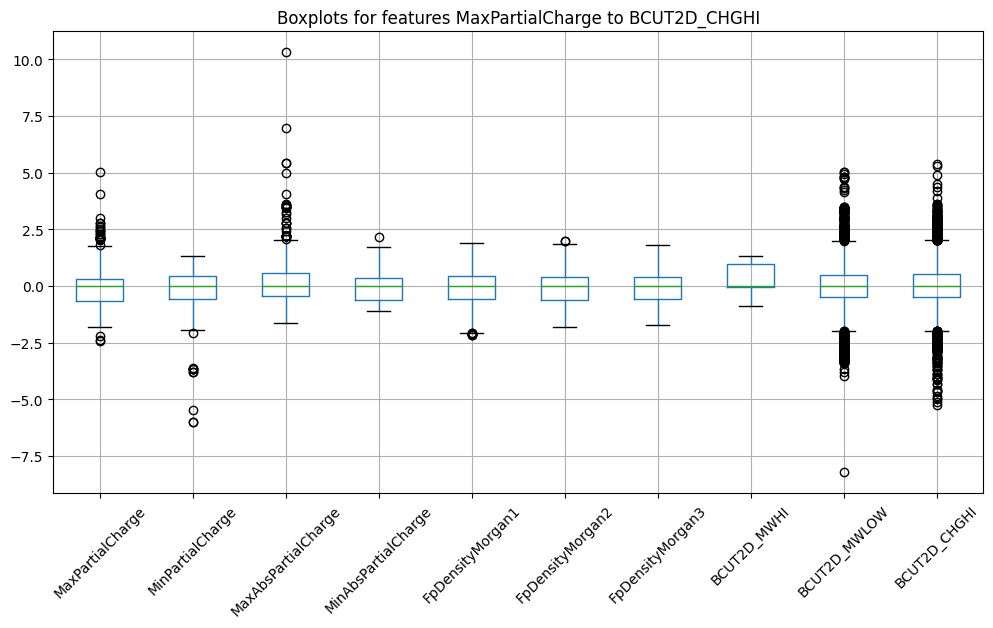

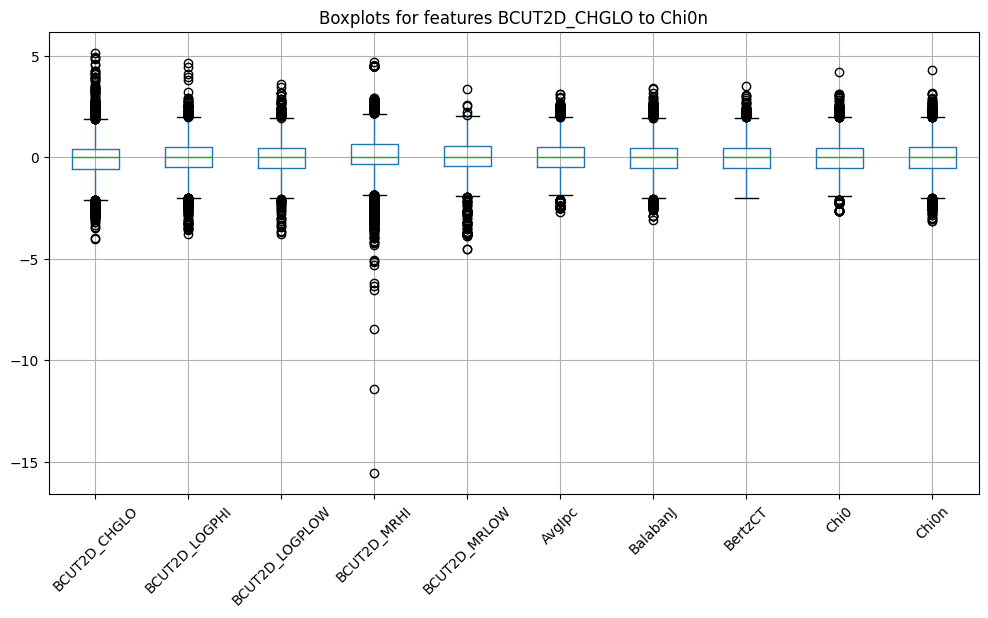

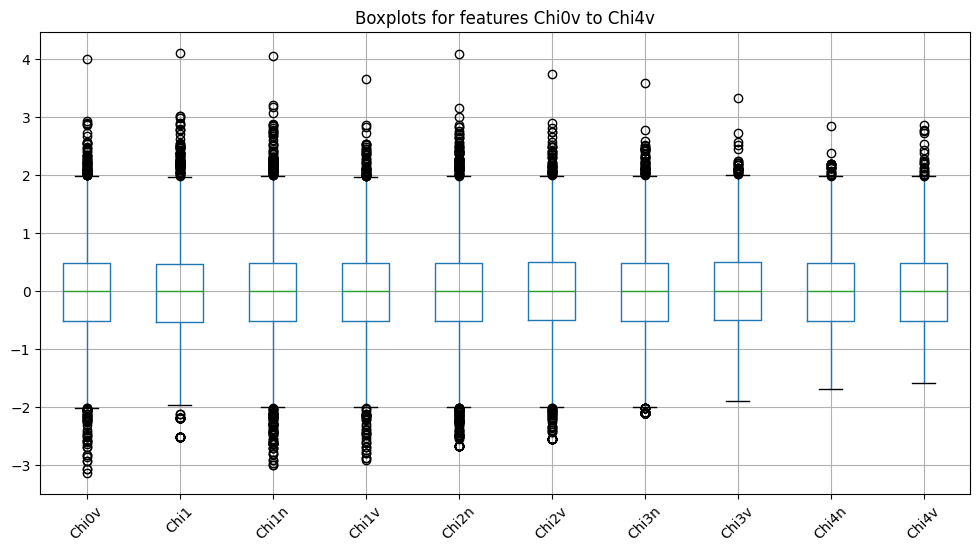

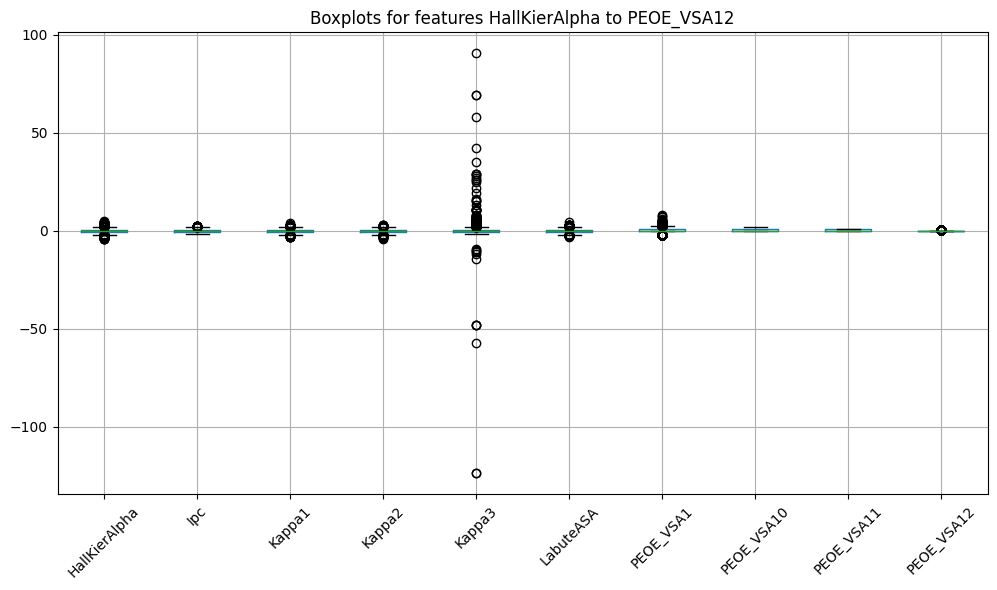

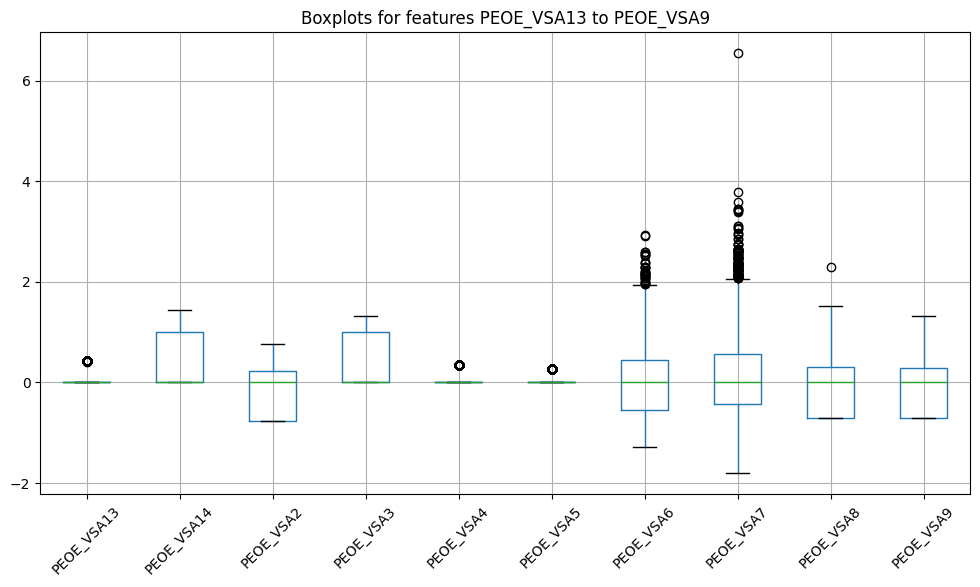

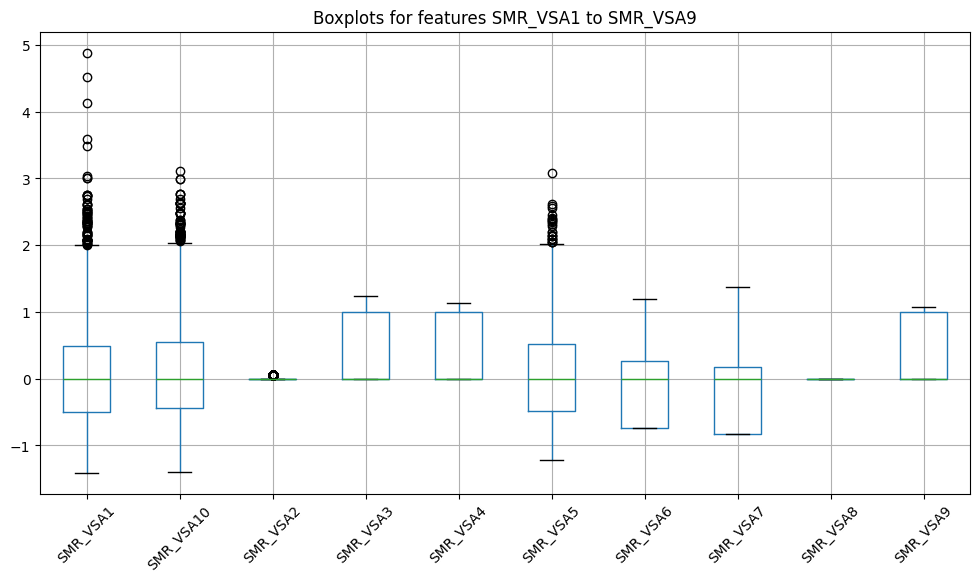

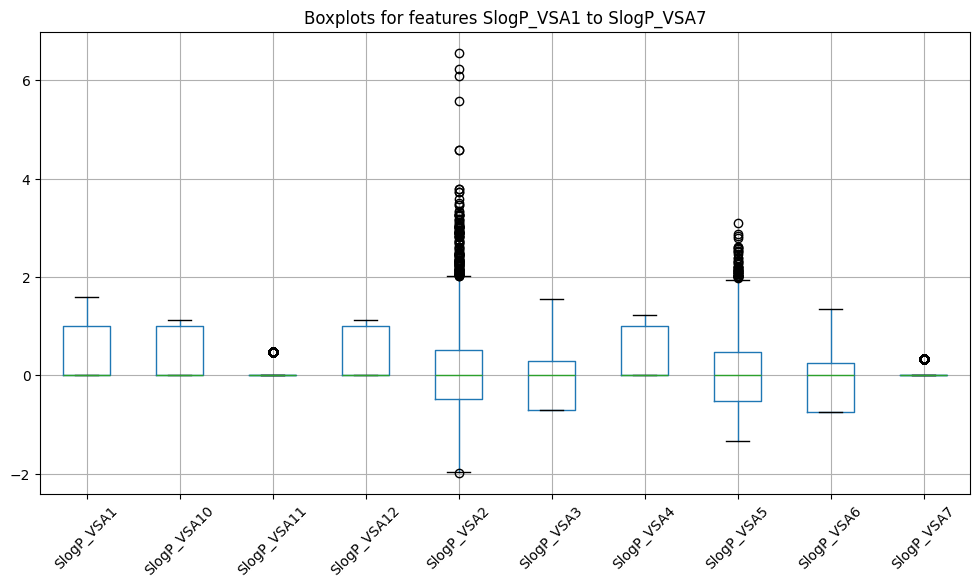

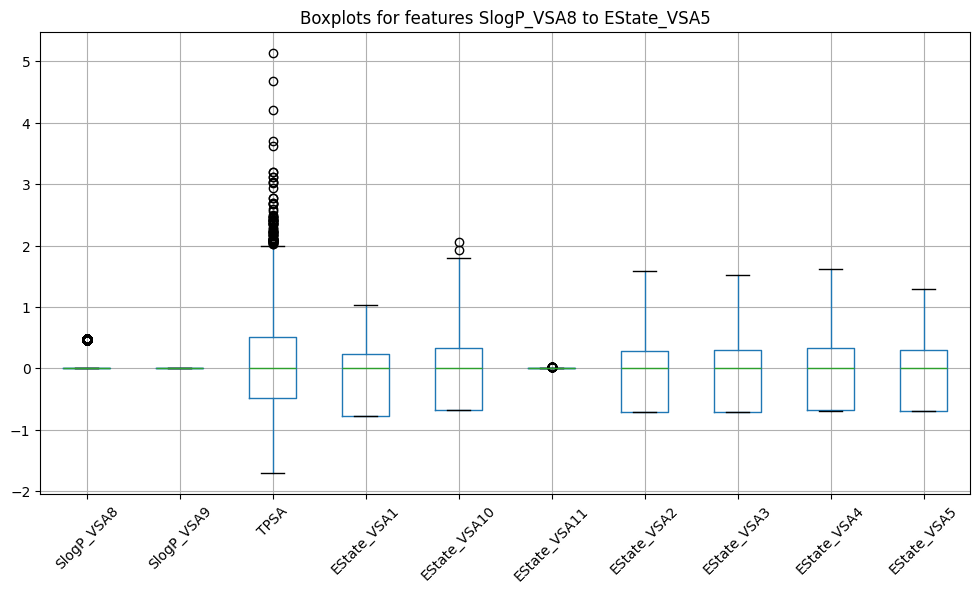

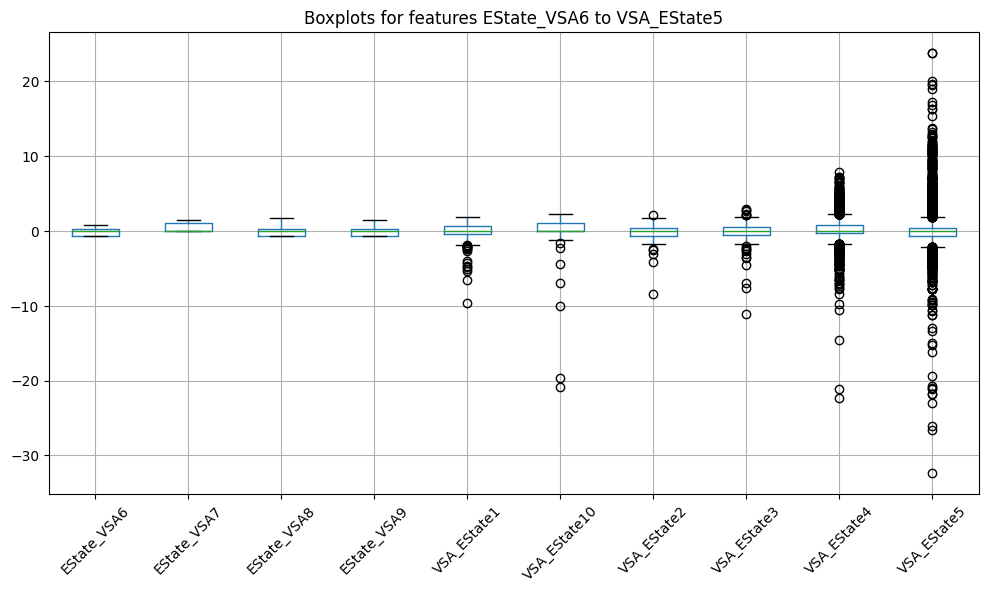

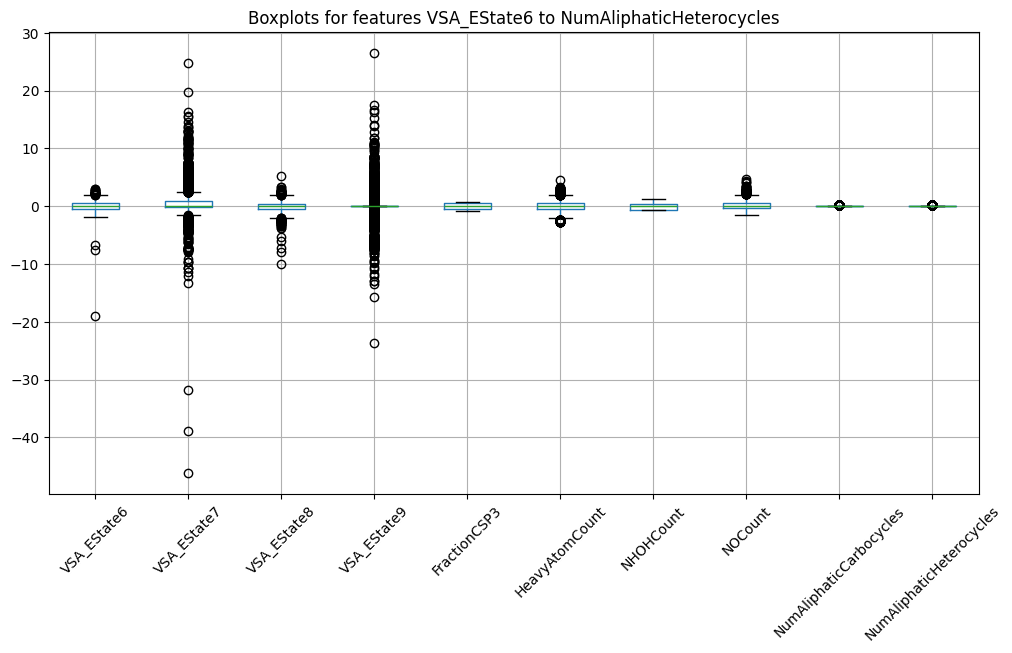

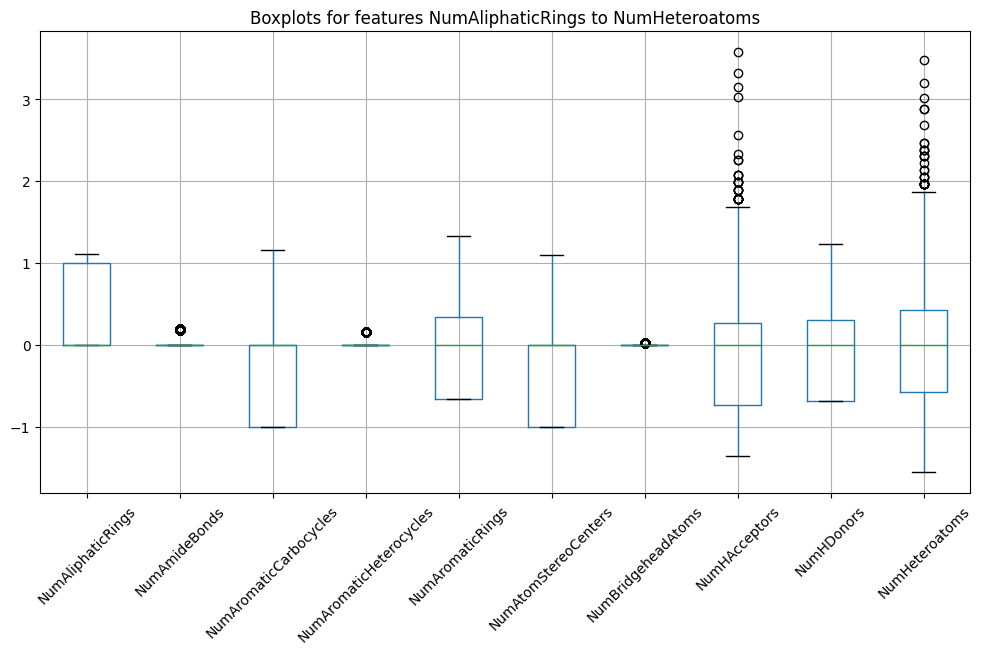

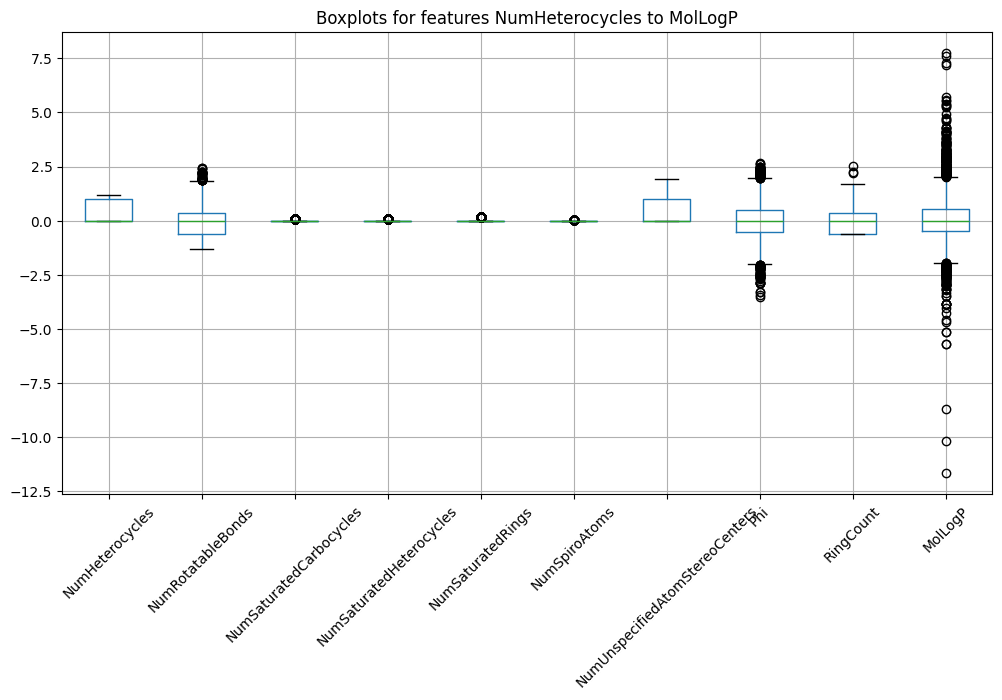

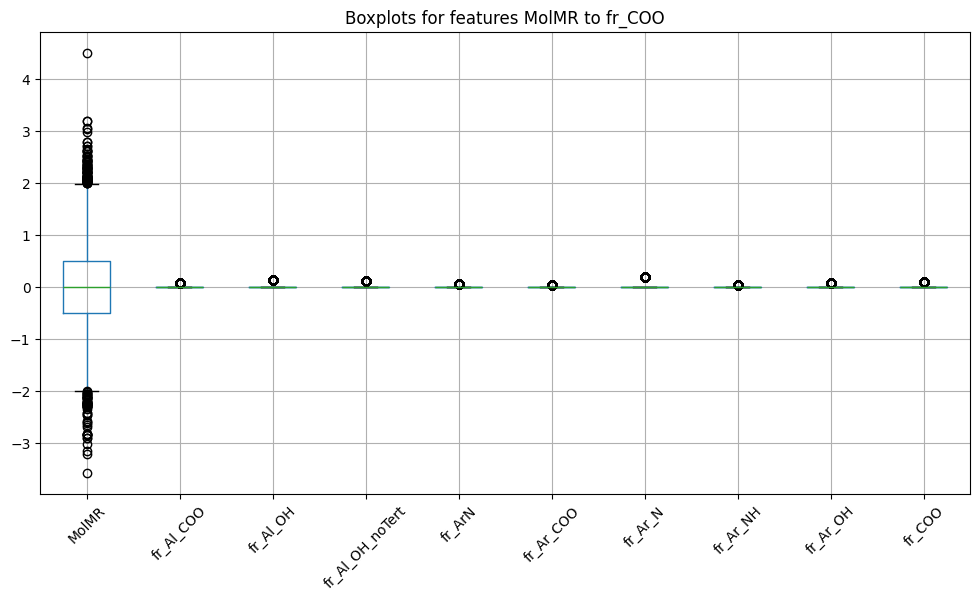

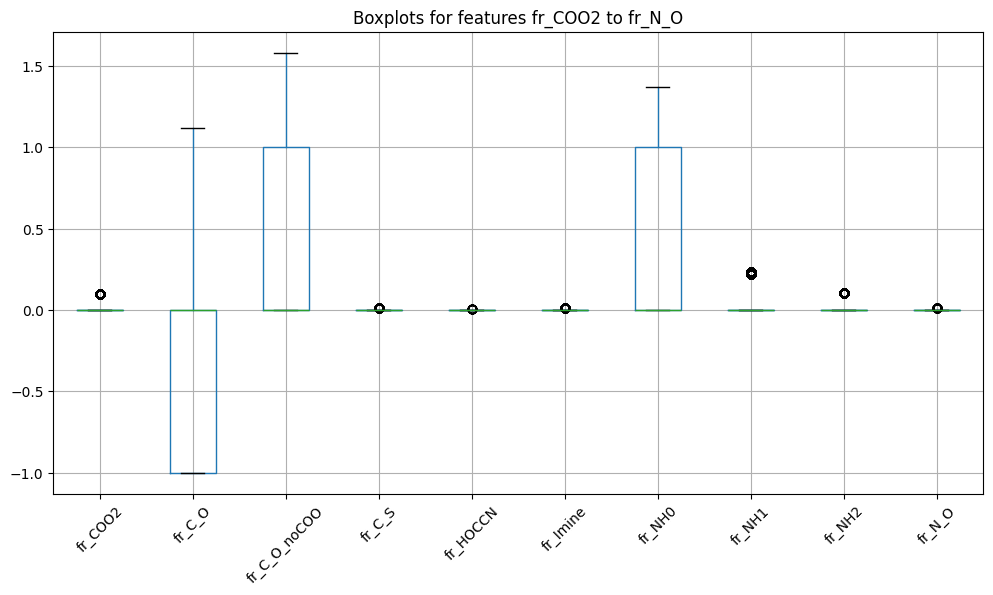

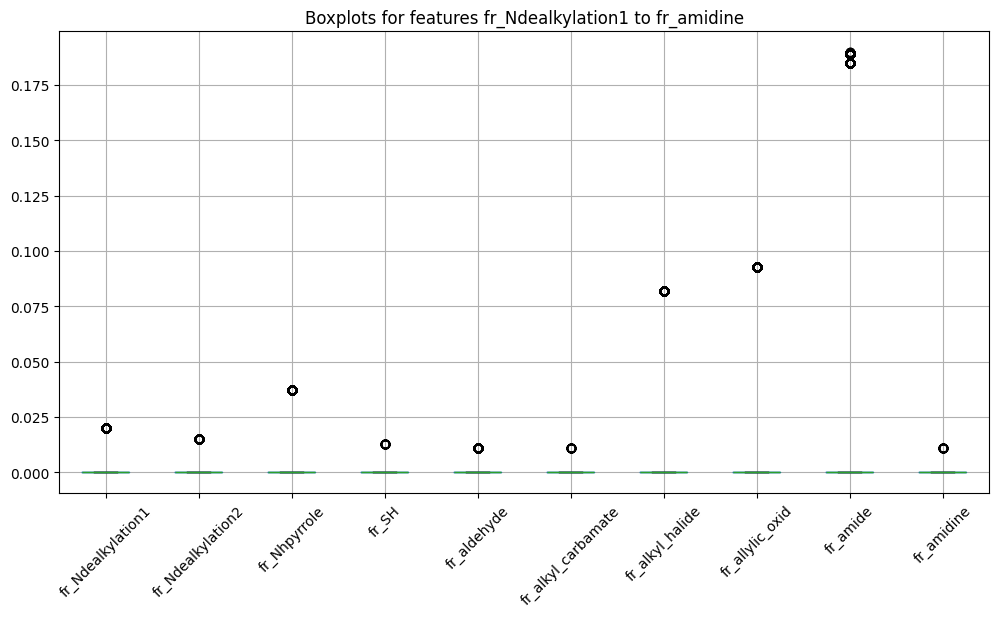

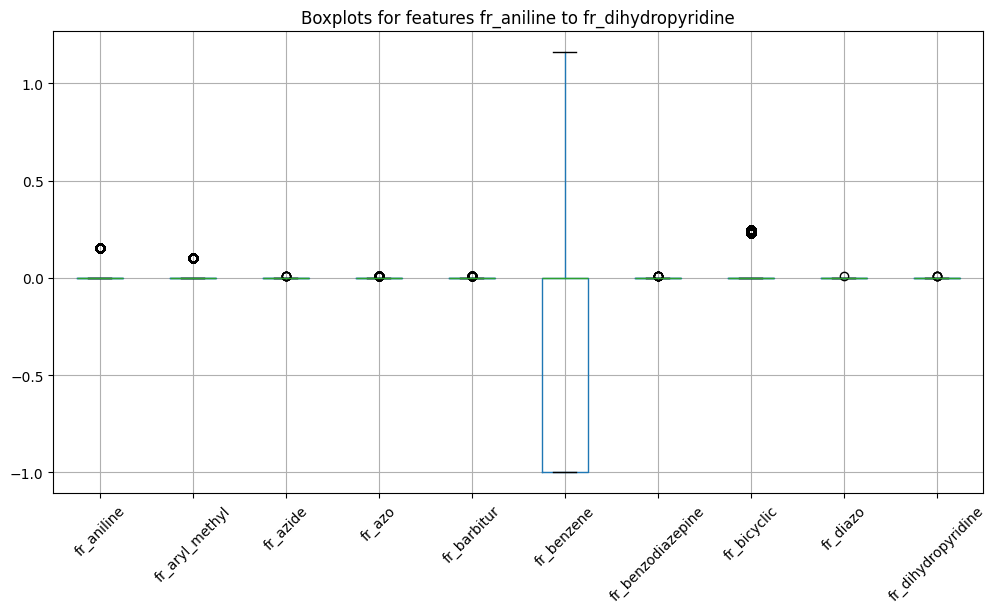

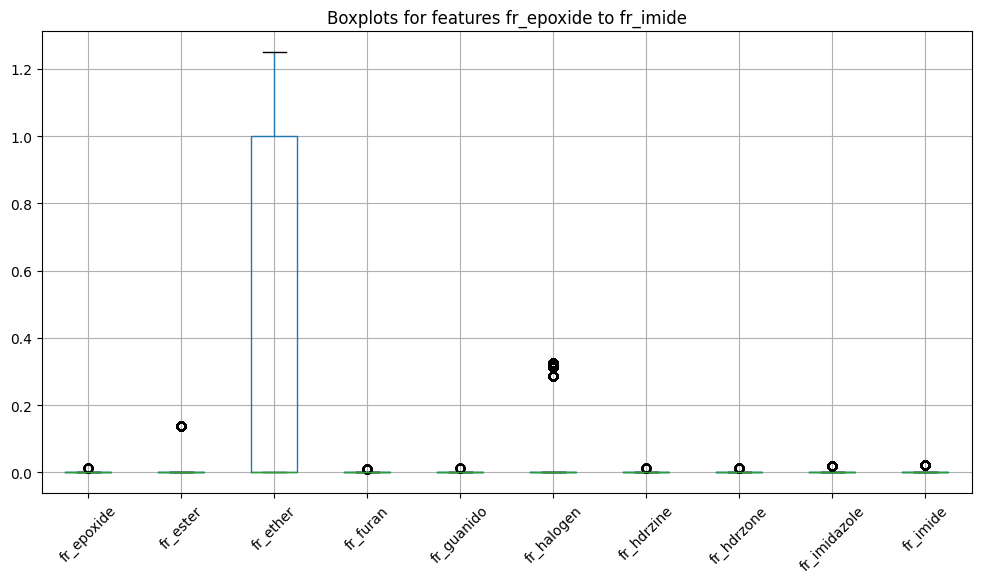

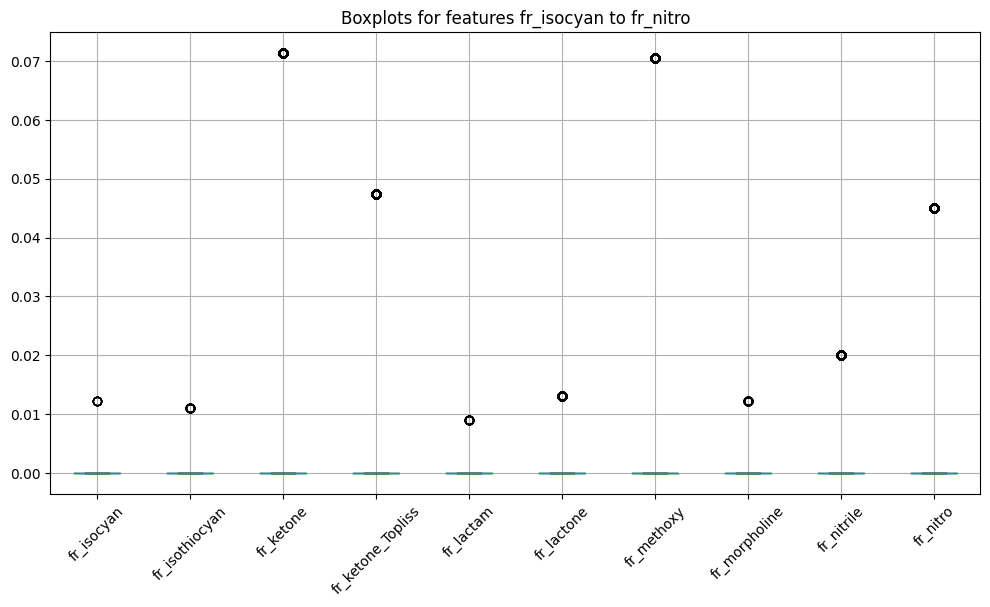

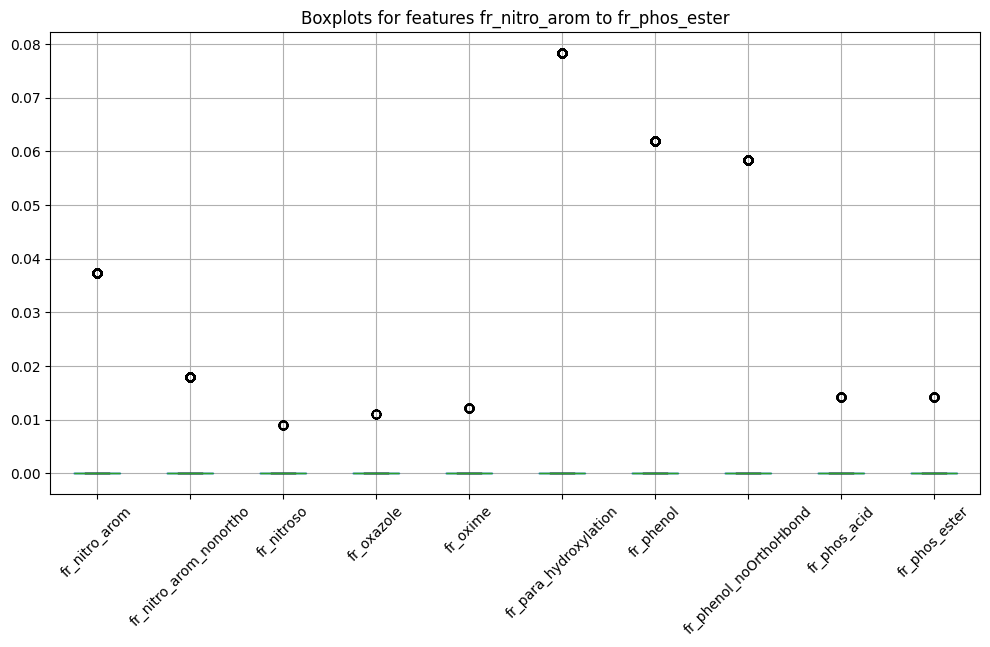

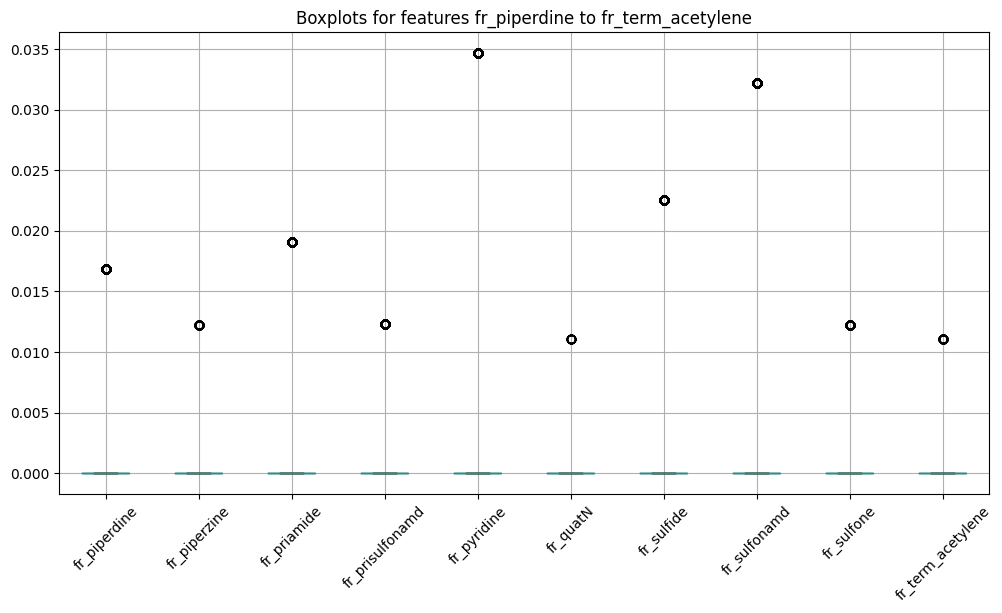

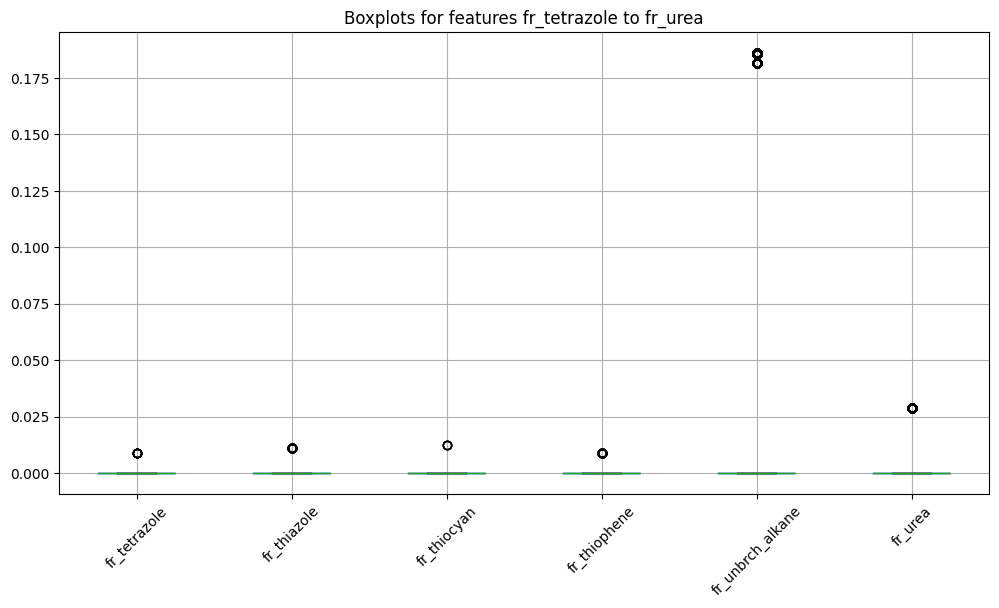

In [ ]:
boxplots(X_transformed)

In [ ]:
df = df.drop([7359, 587]) # , 587

In [ ]:
@np.vectorize
def get_redundant_cols(column):
    return ("solvation_energy" in column and column != "solvation_energy_water") or "avg_partial_charge_" in column or column == "avg_atomic_fukui_minus" or column == "energy"

In [ ]:
drop_cols = X.columns[get_redundant_cols(X.columns)]
drop_cols

Index(['energy', 'solvation_energy_thf', 'solvation_energy_cyclohexane',
       'solvation_energy_dmso', 'avg_partial_charge_cyclohexane',
       'avg_partial_charge_dmso', 'avg_partial_charge_thf',
       'avg_atomic_fukui_minus', 'avg_partial_charge_water'],
      dtype='str')

In [ ]:
X = X.drop(drop_cols, axis=1, errors="ignore")

In [ ]:
def plot_features(X):
    cols = X.columns
    batch_size = 25

    for i in range(0, len(cols), batch_size):
        try:
            batch = cols[i:i+batch_size]
            X[batch].hist(bins=50, figsize=(15, 12))
            plt.suptitle(f"Features {i} to {i+len(batch)}")
            plt.tight_layout()
            plt.show()
        except:
            print(batch)

In [ ]:
coefs = pl["predict"].coef_
coefs[[45, 48]]

for coef, feature in zip(coefs[condition:=(np.abs(coefs) > 100)], df.columns[np.asarray(condition).nonzero()[0]]):
    print(feature, coef)

# print(coefs[np.abs(coefs) > 100])
# df.columns[np.asarray(np.abs(coefs) > 100).nonzero()[0]]

In [ ]:
corr_matrix = X.corr().abs()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

high_corr = (
    upper.unstack()
    .dropna()
    .sort_values(ascending=False)
)

high_corr[high_corr > 0.95]

In [ ]:
corr_target = X.corrwith(y).abs().sort_values(ascending=False)

sorted_features = corr_target.index
corr_sorted = X[sorted_features].corr()

sns.heatmap(corr_sorted)
plt.show()

In [ ]:
np.linalg.cond(X)

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix)
plt.show()